# <CENTER> **PROJECT - Bayesian vs Classical Linear Regression - Apartment Price Prediction**

---

#### **Постановка задачи:**

В данной работе необходимо по имеющимся данным предсказать доход. Необходимо решить задачу регрессии с использованием байесовской модели.

---


#### **Основные цели:**

* Сформировать набор данных на основе предоставленных источников информации;

* Спроектировать новые признаки с помощью *Feature Engineering* и выявить наиболее значимые при построении модели;

* Исследовать предоставленные данные и выявить закономерности;

* Обучить модель байесовской линейной регрессии с выбранными признаками и получить значение метрики на валидации.

---


#### **Этапы работы над проектом:**

Проект будет состоять из шести частей:

`1.` *Базовый анализ и знакомство с данными*;

`2.` *Предобработка и очистка данных*;

`3.` *Разведывательный анализ данных (EDA)*;

`4.` *Feature engineering (Создание новых признаков)*;

`5.` *Machine Learning*;

`6.` *Вывод*.

---

**Импортируем библиотеки**:

In [40]:
# Импортируем необходимые библиотека
import pandas as pd
import numpy as np

# Для построения визуализации
import seaborn as sns
from matplotlib import pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import plotly.offline as py
import arviz as az

# Для построения модели
from sklearn.cluster import KMeans
from prophet import Prophet
from sklearn import metrics
import pymc as pm
from sklearn import model_selection
from sklearn import linear_model

# Для проведения статистических тестов
from scipy import stats

**Загружаем данные:**

In [2]:
# Загружаем датасет
flats_data = pd.read_csv('data/flats.csv')

# Создаём копию
flats_df = flats_data.copy()

=============================================================================================================================================

## <center> **`1.` Базовый анализ и знакомство с данными**

На данном этапе изучим информацию предоставленных данных.

#### $1.1$

##### **Выведем информацию по таблицам.**

Создаём функцию:

In [3]:
# Создадим функцию для вывода информации по датасету
def check_data_inf(data, data_name = None, length1 = None, length2 = None):
    
    # Выводим размеры таблицы
    print(f'\nДанные таблицы "{data_name}" имеют следующую размерность:\n')
    print('Количество строк: {};\nКоличество признаков (столбцов): {}.'.format(data.shape[0], data.shape[1]))
    print('-' * length1)

    # Выведем первые пять строк 
    display(data)
    print('-' * length2)

Выводим результат:

In [4]:
# Выводим информацию по полученной таблице при помощи функции 'check_data_inf'
check_data_inf(
    data = flats_df,
    data_name = 'flats_df',
    length1 = 40,
    length2 = 65
)


Данные таблицы "flats_df" имеют следующую размерность:

Количество строк: 6042;
Количество признаков (столбцов): 6.
----------------------------------------


,Unnamed: 0,price_doc,full_sq,life_sq,num_room,kitch_sq
0,8056,2750000,11,11.0,1.0,12.0
1,8154,7100000,45,27.0,2.0,6.0
2,8287,11700000,77,50.0,3.0,8.0
3,8387,10400000,56,29.0,2.0,10.0
4,8391,6200000,31,21.0,1.0,5.0
...,...,...,...,...,...,...
6037,30462,10544070,47,30.0,1.0,10.0
6038,30463,12000000,56,29.0,2.0,11.0
6039,30467,25000000,86,59.0,4.0,10.0
6040,30469,13500000,64,32.0,2.0,11.0


-----------------------------------------------------------------


#### **Основные характеристики:**

Датасет содержит информацию о квартирах. Целевой переменной является столбец `price_doc`. Данная переменная обозначает стоимость жилья.

В датафрейме представлен следующий набор признаков:

* `full_sq` - полная площадь квартиры;

* `life_sq` - жилая площадь;

* `kitch_sq` - площадь кухни;

* `num_room` - количество комнат;

* `Unnamed: 0` - неизвестный признак;

**Целевой признак:**

* `price_doc` - стоимость квартиры.

---

#### $1.2$

Выведем информацию по признакам:

In [5]:
# Вывод таблицы 'flats_df'
print('\nИнформация датасета "flats_df":\n')
display(flats_df.info())
print('-' * 55)


Информация датасета "flats_df":

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6042 entries, 0 to 6041
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  6042 non-null   int64  
 1   price_doc   6042 non-null   int64  
 2   full_sq     6042 non-null   int64  
 3   life_sq     6042 non-null   float64
 4   num_room    6042 non-null   float64
 5   kitch_sq    6042 non-null   float64
dtypes: float64(3), int64(3)
memory usage: 283.3 KB


None

-------------------------------------------------------


#### $1.3$

##### **Подсчитаем количество типов данных по признакам.**

Создаём функцию для подсчёта:

In [6]:
# Создаём функцию для рассчёта количества типов по признакам
def check_features_dtypes(data, data_name = None, length1 = None, length2 = None):
    
    # Подсчет количества признаков типа 'object', 'int64' и 'float64'      
    object_columns_count = data.select_dtypes(include = ['object']).shape[1]
    int64_columns_count = data.select_dtypes(include = ['int64']).shape[1]
    float64_columns_count = data.select_dtypes(include = ['float64']).shape[1]
    bool_columns_count = data.select_dtypes(include = ['bool']).shape[1]


    # Вывод результата
    print(f'\nВ таблице "{data_name}" представлены признаки следующих типов:')
    print('-' * length1)
    print()

    print(f"Количество признаков типа 'object': {object_columns_count}")
    print(f"Количество признаков типа 'int64': {int64_columns_count}")
    print(f"Количество признаков типа 'float64': {float64_columns_count}")
    print(f"Количество признаков типа 'bool': {bool_columns_count}")
    print('-' * length2)

Выводим результат:

In [7]:
# Выводим данные таблицы 'flats_df'
check_features_dtypes(
    data = flats_df,
    data_name =  'flats_df',
    length1 = 70,
    length2 = 45
)


В таблице "flats_df" представлены признаки следующих типов:
----------------------------------------------------------------------

Количество признаков типа 'object': 0
Количество признаков типа 'int64': 3
Количество признаков типа 'float64': 3
Количество признаков типа 'bool': 0
---------------------------------------------


#### $1.4$

Выведем описательные характеристики по признакам:

In [8]:
# Вывод таблицы
print('\nОписательные характеристики датасета "flats_df":\n')
display(flats_df.describe())
print('-' * 123)


Описательные характеристики датасета "flats_df":



,Unnamed: 0,price_doc,full_sq,life_sq,num_room,kitch_sq
count,6042.000000,6.042000e+03,6042.000000,6042.000000,6042.000000,6042.000000
mean,19846.990070,8.750423e+06,53.374545,33.198941,1.997021,7.391096
std,6081.011373,6.277290e+06,24.011941,20.190005,0.889523,3.806198
min,8056.000000,5.000000e+05,1.000000,0.000000,0.000000,0.000000
25%,14573.250000,5.800000e+06,38.000000,20.000000,1.000000,5.000000
50%,19871.500000,7.400000e+06,46.000000,29.000000,2.000000,7.000000
75%,25147.750000,1.050000e+07,63.000000,42.000000,3.000000,9.000000
max,30470.000000,9.512250e+07,637.000000,637.000000,17.000000,96.000000


---------------------------------------------------------------------------------------------------------------------------


=============================================================================================================================================

## <center> **`2.` Предобработка и очистка данных**

На данном этапе выявим и очистим данные от пропусков, дубликатов и выбросов.

#### $2.1$

##### **Проверим данные на наличие пропусков.**

Создаём функцию для рассчёта пропусков:

In [9]:
# Создаём функцию для подсчёта суммарного количества пропусков
def missing_values_count(data, data_name = None, length = None):
    
    # Выводим суммарное количество пропусков
    print('\nСуммарное количество пропусков в таблице "{}": {} \n'.format(data_name, data.isnull().sum().sum()))

    # Выводим признаки с сумрным количеством пропусков
    print('Информация по количествам пропусков: \n\n{} \n'.format(data.isnull().sum()))
    print('-' * length)

Выводим результаты тренировочной выборки:

In [10]:
# Выводим количество пропусков
missing_values_count(
    data = flats_df,
    data_name = 'flats_df',
    length = 70
)


Суммарное количество пропусков в таблице "flats_df": 0 

Информация по количествам пропусков: 

Unnamed: 0    0
price_doc     0
full_sq       0
life_sq       0
num_room      0
kitch_sq      0
dtype: int64 

----------------------------------------------------------------------


Исходя из полученной информации, в данных полностью отсутствуют пропущенные значения.

#### $2.2$

**Проверяем данные на наличие дубликатов:**

In [11]:
# Создаём список признаков
dupl_columns = list(flats_df.columns)


# Создаём маску дубликатов с помощью метода duplicated() и произведём фильтрацию
mask = flats_df.duplicated(subset = dupl_columns)
winequality_duplicates = flats_df[mask]
print(f'\nЧисло найденных дубликатов: {winequality_duplicates.shape[0]}')


Число найденных дубликатов: 0


В данных так же отсутствуют дубликаты.

=============================================================================================================================================

## <center> **`3.` Разведывательный анализ данных (EDA)**

На данном этапе проведём небольшой анализ данных и построим несколько визуализаций.

#### $3.1$

Для начала, прологорифмируем целевую переменную:

In [12]:
# Создаём логорифмический признак целевой переменной
flats_df['log_price'] = np.log(flats_df['price_doc'])


# Выведем результат
print('\nПервые 5 строк признака "log_price":\n')
display(flats_df['log_price'].head())
print('-' * 35)


Первые 5 строк признака "log_price":



0    14.827111
1    15.775605
2    16.275099
3    16.157316
4    15.640060
Name: log_price, dtype: float64

-----------------------------------


#### $3.2$

#### **Корреляционный анализ.**

Создаём функцию для построения тепловой карты корреляции признаков:

In [13]:
# Создаём функцию 'heatmap_corr()' для построения тепловой карты корреляции
def heatmap_corr(data, title = None, figsize = None, cmap = None):
    
    
    """
    Функция для построения тепловой карты корреляции.
    
    Параметры:
    data (DataFrame): Данные для анализа.
    title (str): Заголовок графика.
    figsize (tuple): Размер графика.
    
    """
    
    
    # Создаём заголовок для графика
    print('\nТепловая карта корреляции признаков:')
    print('-' * 123)
    
    
    # Задаём размер полотна
    plt.rcParams['figure.figsize'] = figsize
    
    # Строим тепловую карту
    sns.heatmap(
        data.corr(),
        mask = np.triu(np.ones_like(data.corr(), dtype = bool)),
        annot = True,
        fmt = '.2f',
        cmap = cmap,
        vmin = -1, 
        vmax = 1, 
        center = 0,
        square = True,
        cbar_kws = {'shrink': .8},
        linewidths = 0.5,
        linecolor = 'black',
        annot_kws = {'size': 10, 'weight': 'bold', 'color': 'black'},
        cbar = True
    )
    
    # Настраиваем параметры
    plt.title(title, fontsize = 20)
    plt.tight_layout()
    
    # Выводим график
    plt.show()
    print('-' * 123)

Проверим корреляцию признаков:


Тепловая карта корреляции признаков:
---------------------------------------------------------------------------------------------------------------------------


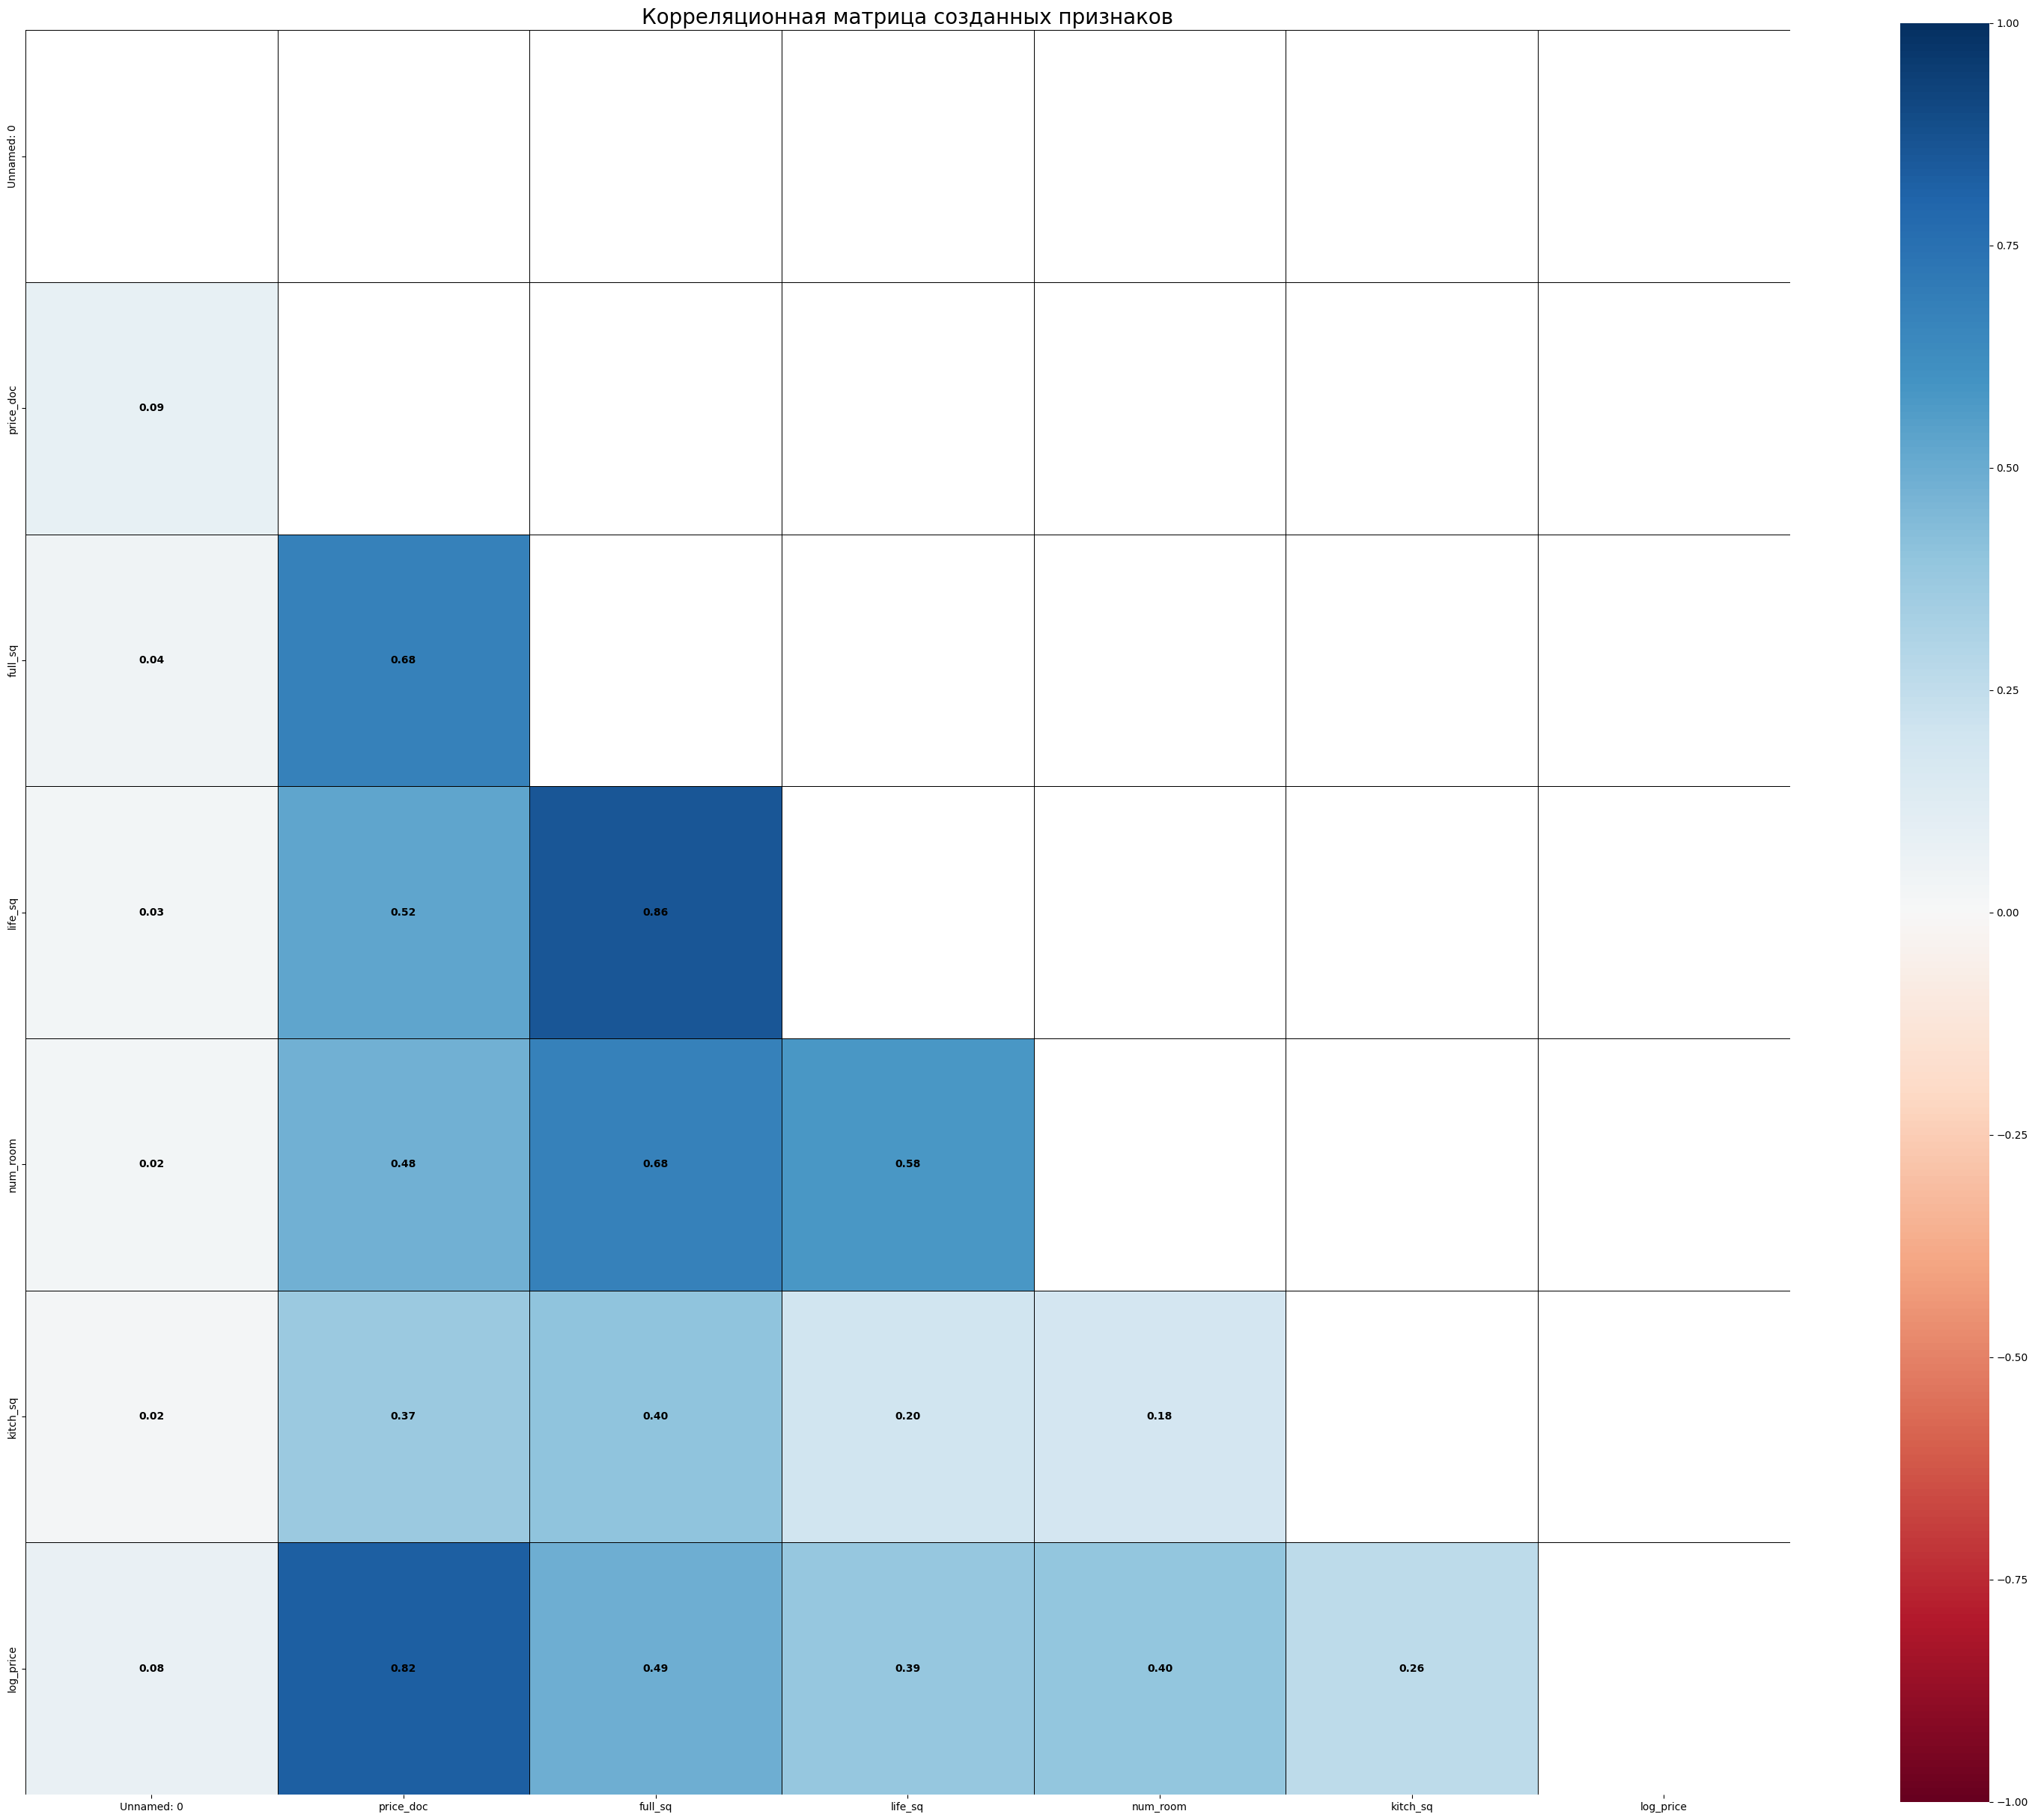

---------------------------------------------------------------------------------------------------------------------------


In [14]:
# Повторно построим тепловую карту
heatmap_corr(
    data = flats_df,
    title = 'Корреляционная матрица созданных признаков',
    figsize = (30, 30),
    cmap = 'RdBu'
)

**Вывод:**

Исходя из построенной тепловой карты максимальное значение корреляции не превышает $0.86$, что вполне допустимо, следовательно высококоррелированных связей небыло обнаружено.

#### $3.3$

#### **Распределение признаков.**

Проверим распределение всех признаков.

Для этого используем **тест Шапиро-Уилка** чтобы провести анализ распределения всех признаков:

In [15]:
# Задаём уровень значимости
alpha = 0.05



# Создаём цикл по всем признакам
for column in flats_df.columns:
    
    # Выводим заголовок для текущей переменной
    print()
    print(f'\nТестирование нормальности распределения для "{column}":')
    print()
    
    # Выполняем тест Шапиро-Уилка
    stat, p_value = stats.shapiro(flats_df[column].dropna())
    
    # Выводим результаты теста
    print(f'Статистика: {stat:.4f}, p-значение: {p_value:.4f}')
    
    # Проверяем гипотезу
    if p_value > alpha:
        print(f'Распределение признака "{column}" нормально (не отвергаем гипотезу H0)')
    else:
        print(f'Распределение признака "{column}" не нормально (отвергаем гипотезу H0)')
        
    print('-' * 80)
    print('\n')



Тестирование нормальности распределения для "Unnamed: 0":

Статистика: 0.9582, p-значение: 0.0000
Распределение признака "Unnamed: 0" не нормально (отвергаем гипотезу H0)
--------------------------------------------------------------------------------




Тестирование нормальности распределения для "price_doc":

Статистика: 0.7401, p-значение: 0.0000
Распределение признака "price_doc" не нормально (отвергаем гипотезу H0)
--------------------------------------------------------------------------------




Тестирование нормальности распределения для "full_sq":

Статистика: 0.7720, p-значение: 0.0000
Распределение признака "full_sq" не нормально (отвергаем гипотезу H0)
--------------------------------------------------------------------------------




Тестирование нормальности распределения для "life_sq":

Статистика: 0.6536, p-значение: 0.0000
Распределение признака "life_sq" не нормально (отвергаем гипотезу H0)
-------------------------------------------------------------------------

c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning:

scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 6042.



Построим графики распределения прологорифмированной целевой переменной для визуального сравнения:


График распределения признака "log_price":
---------------------------------------------------------------------------------------------------------------------------


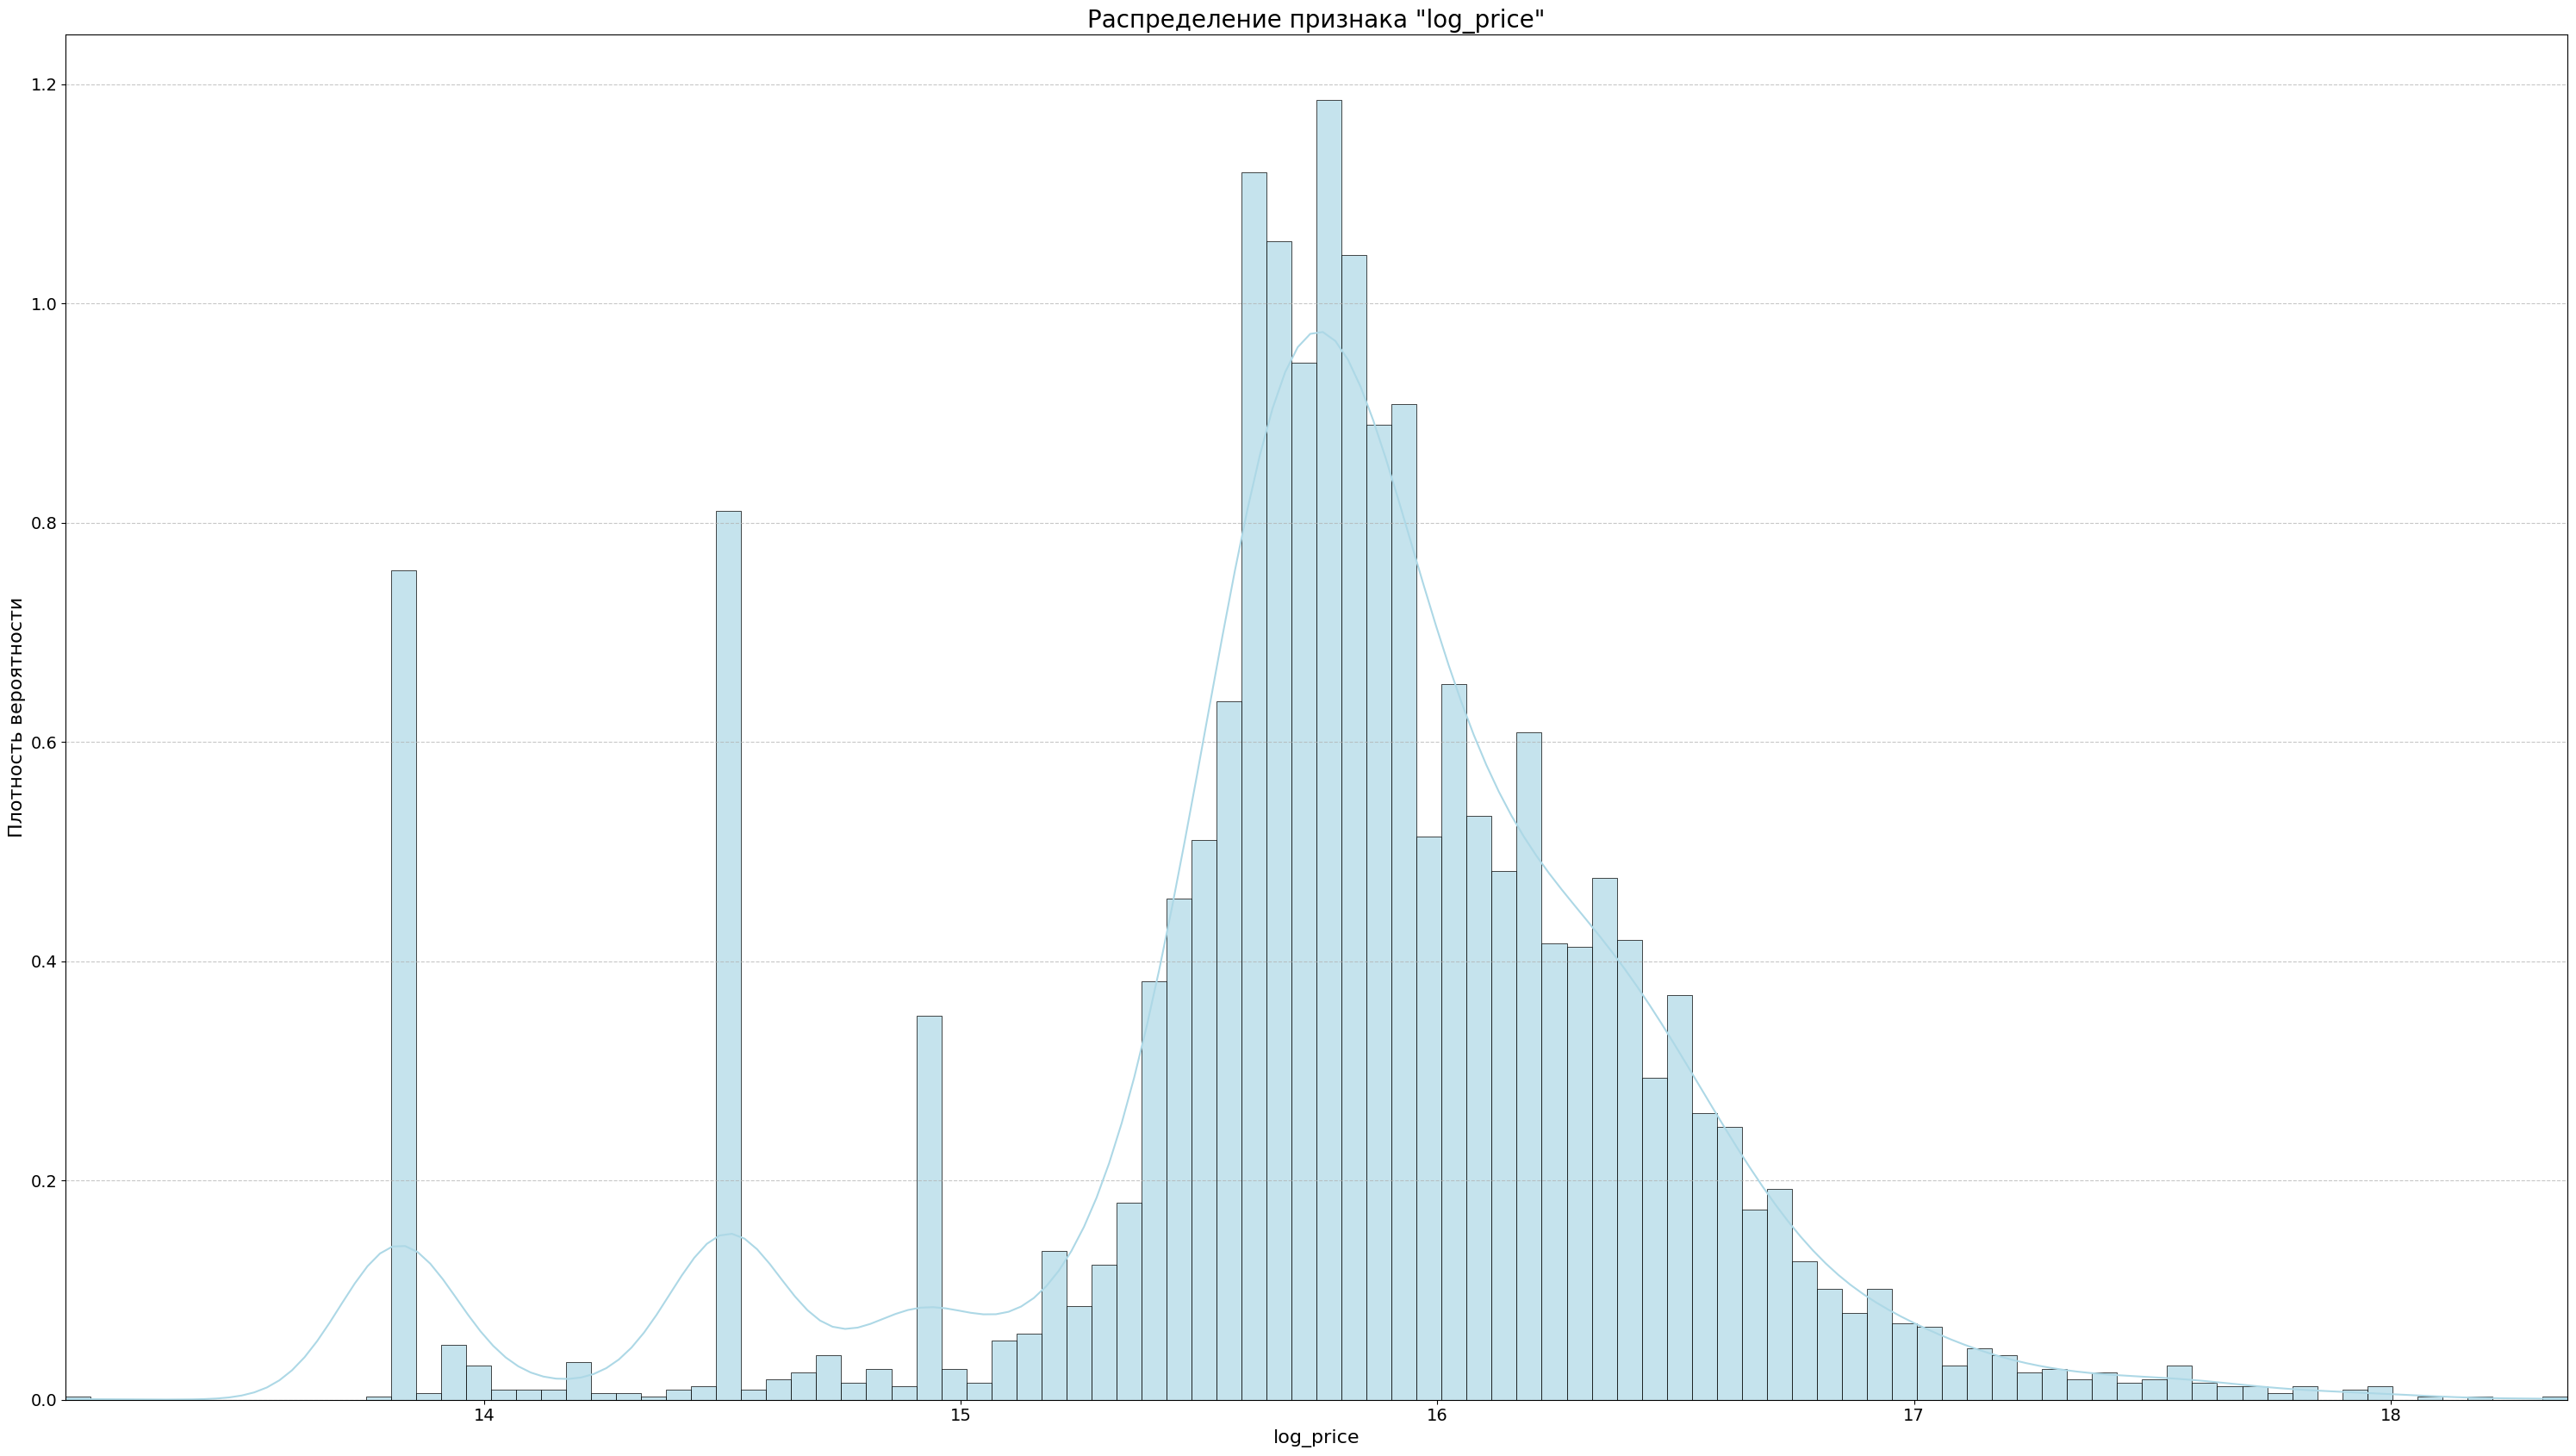

---------------------------------------------------------------------------------------------------------------------------


In [16]:
# Задаём заголовок для графика
print('\nГрафик распределения признака "log_price":')
print('-' * 123)



# Задаём размер полотна
plt.rcParams['figure.figsize'] = (30, 17)

# Строим график распределения прологорифмированной целевой переменной для визуального сравнения:
sns.histplot(
    data = flats_df,
    x = 'log_price',
    kde = True,
    bins = 100,
    stat = 'density',
    color = 'lightblue',
    fill = True,
    edgecolor = 'black',
    linewidth = 0.5,
    alpha = 0.7
)

# Настраиваем параметры
plt.title('Распределение признака "log_price"', fontsize = 20)
plt.xlabel('log_price', fontsize = 16)
plt.ylabel('Плотность вероятности', fontsize = 16)
plt.xlim(flats_df['log_price'].min(), flats_df['log_price'].max())
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)
plt.tight_layout()

# Выводим график
plt.show()
print('-' * 123)

Теперь построим графики распределения площадей квартир:



График распределения признака "full_sq":
---------------------------------------------------------------------------------------------------------------------------


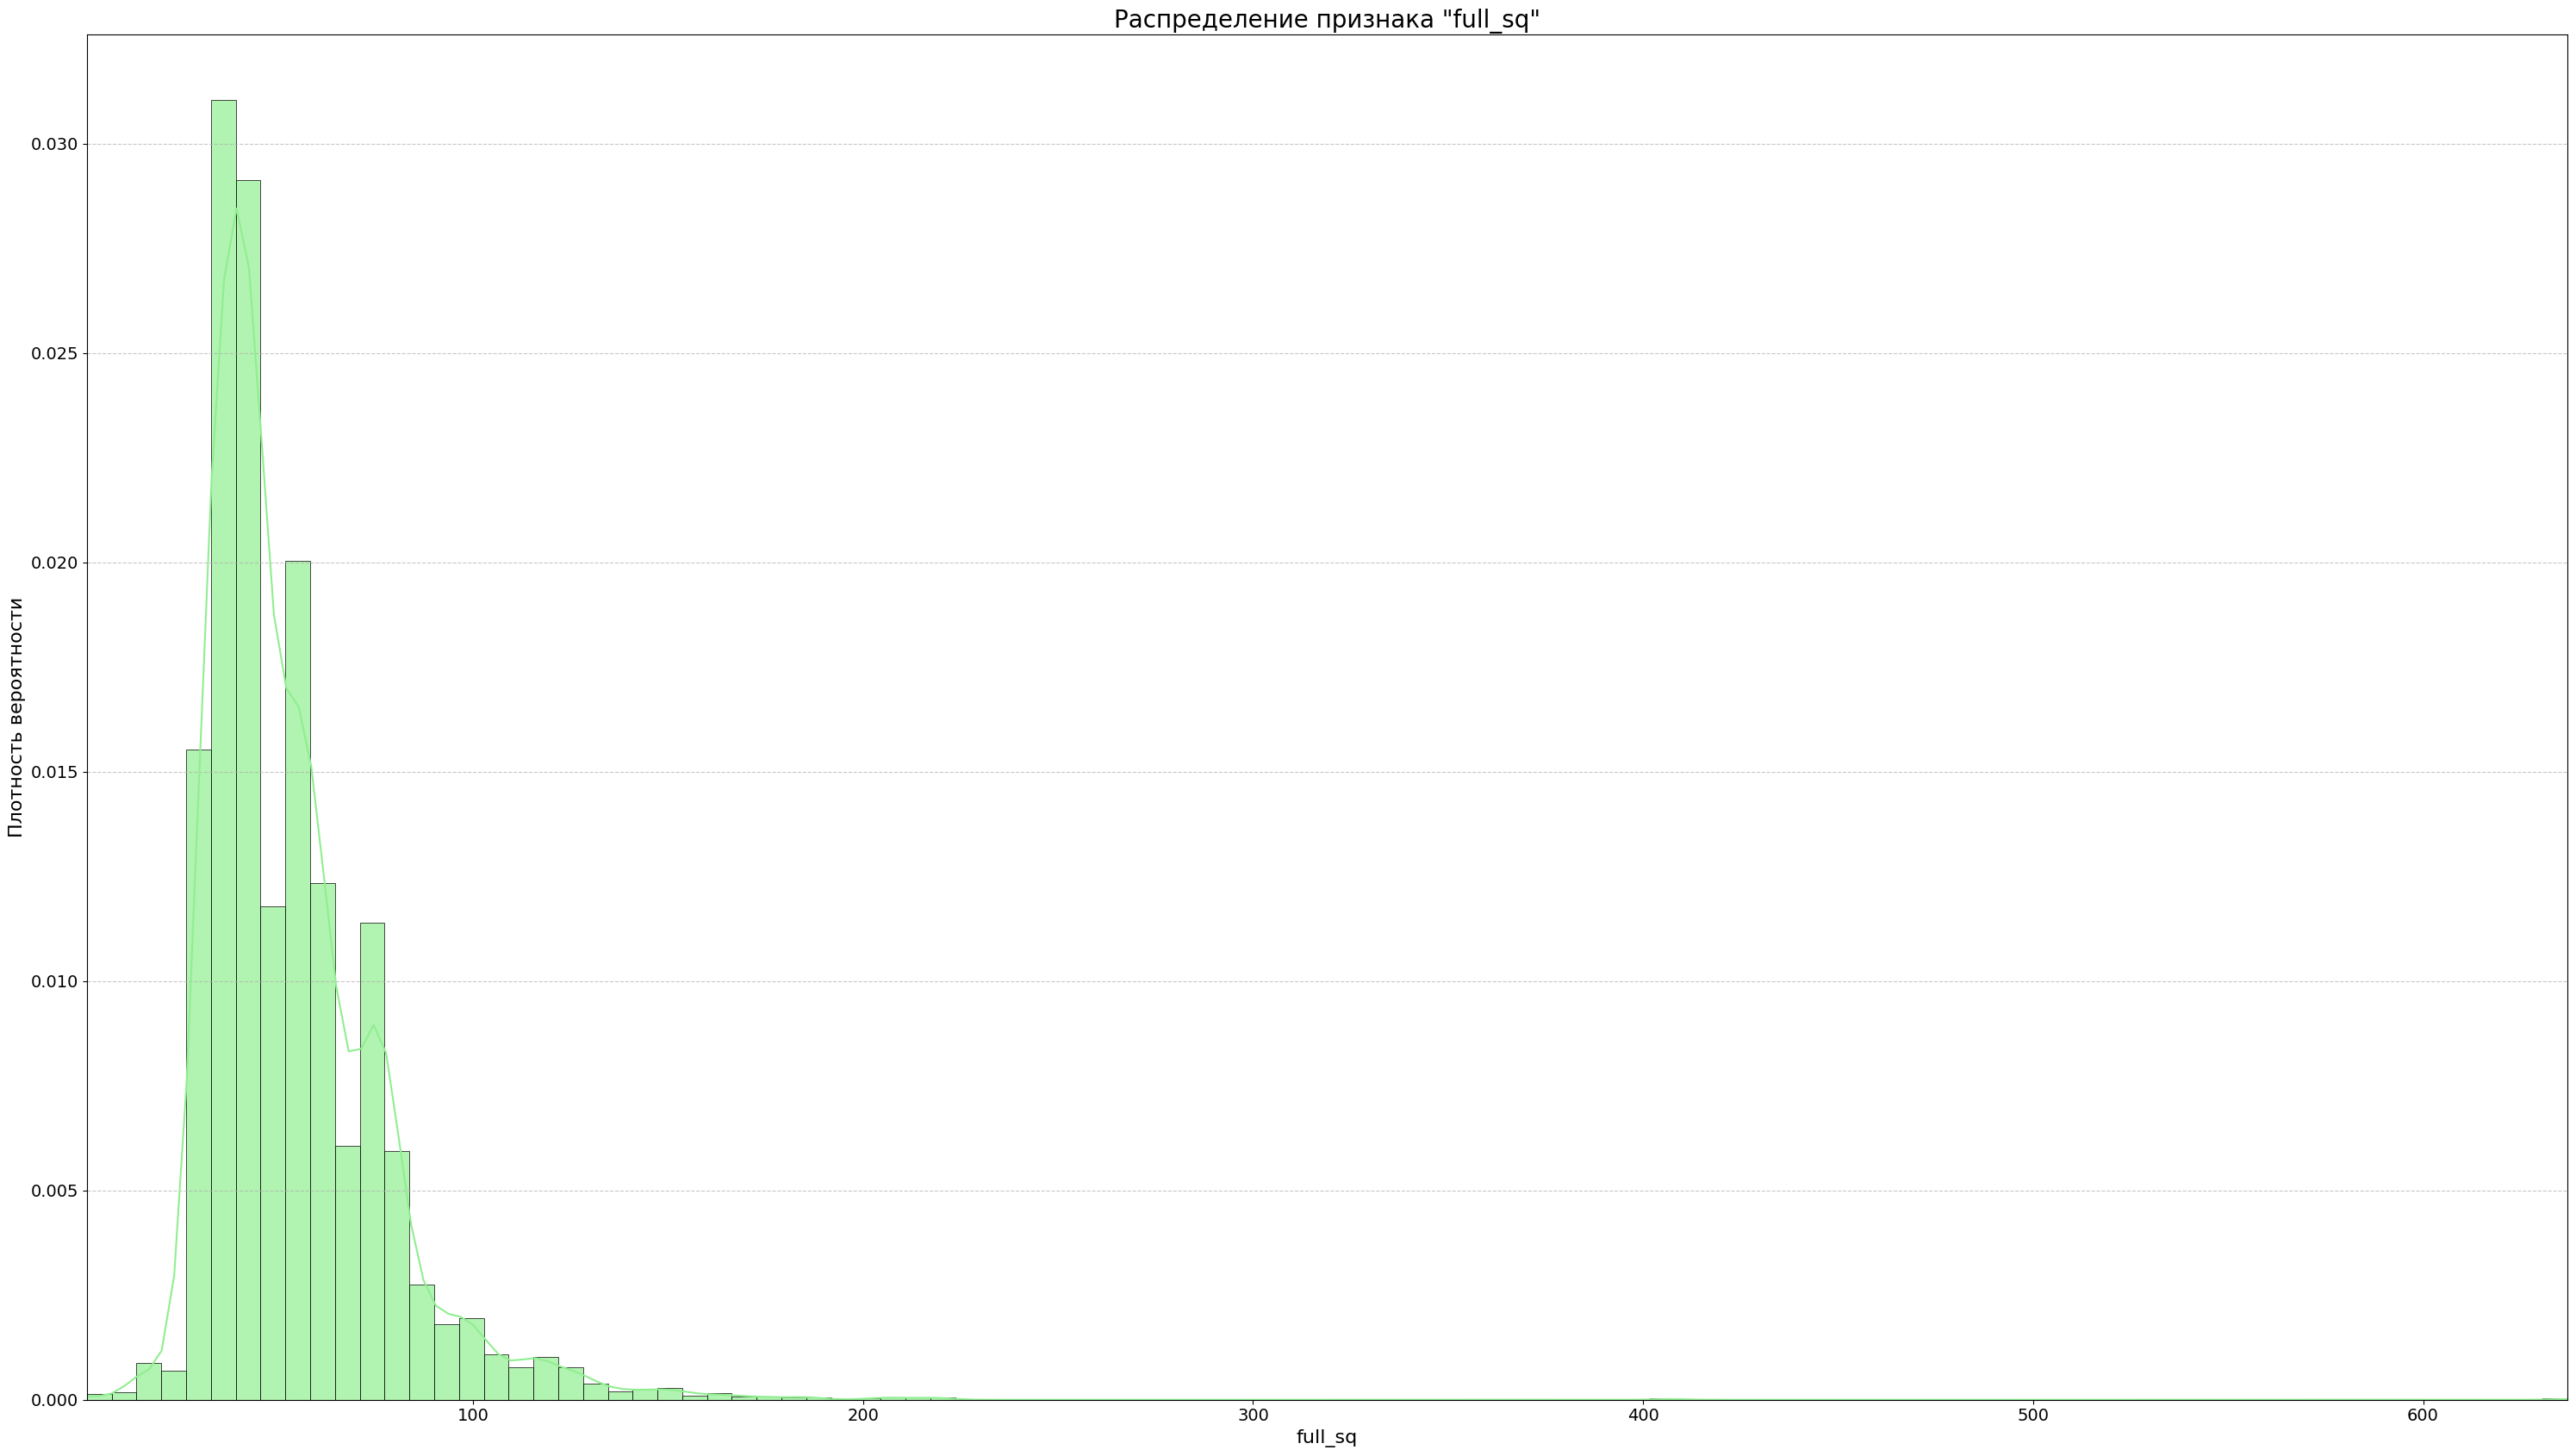

---------------------------------------------------------------------------------------------------------------------------


График распределения признака "life_sq":
---------------------------------------------------------------------------------------------------------------------------


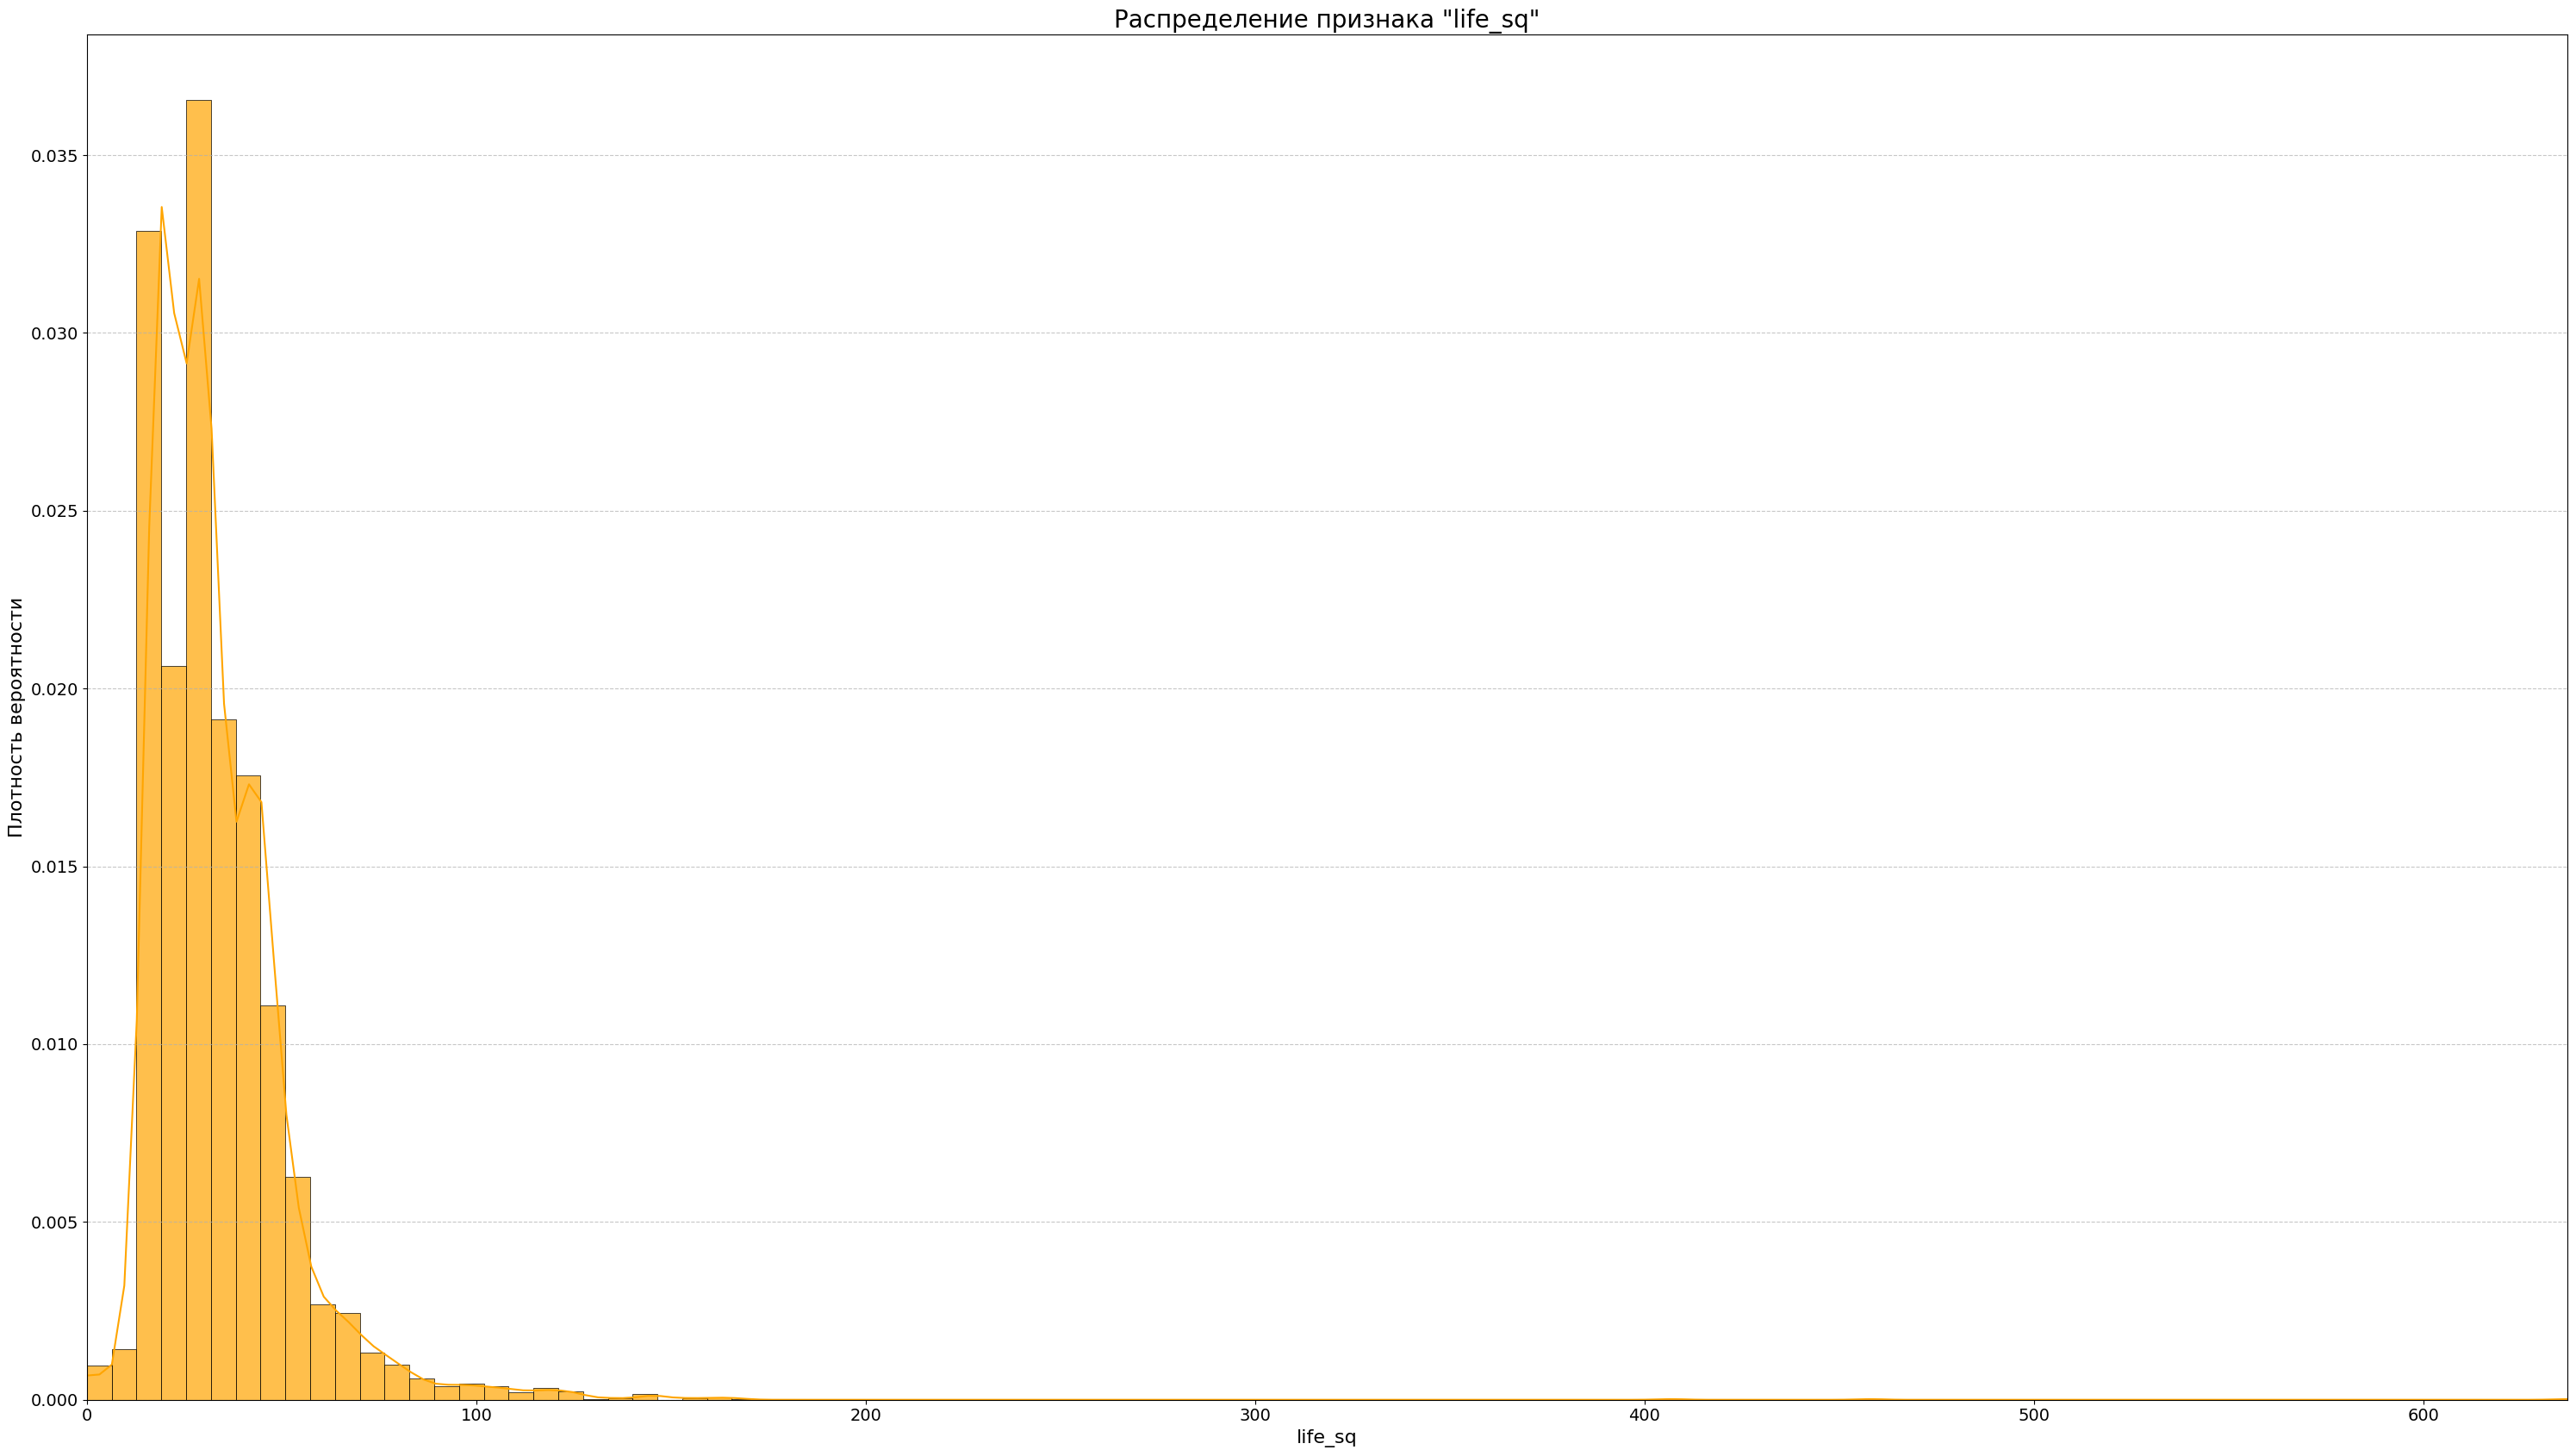

---------------------------------------------------------------------------------------------------------------------------


График распределения признака "kitch_sq":
---------------------------------------------------------------------------------------------------------------------------


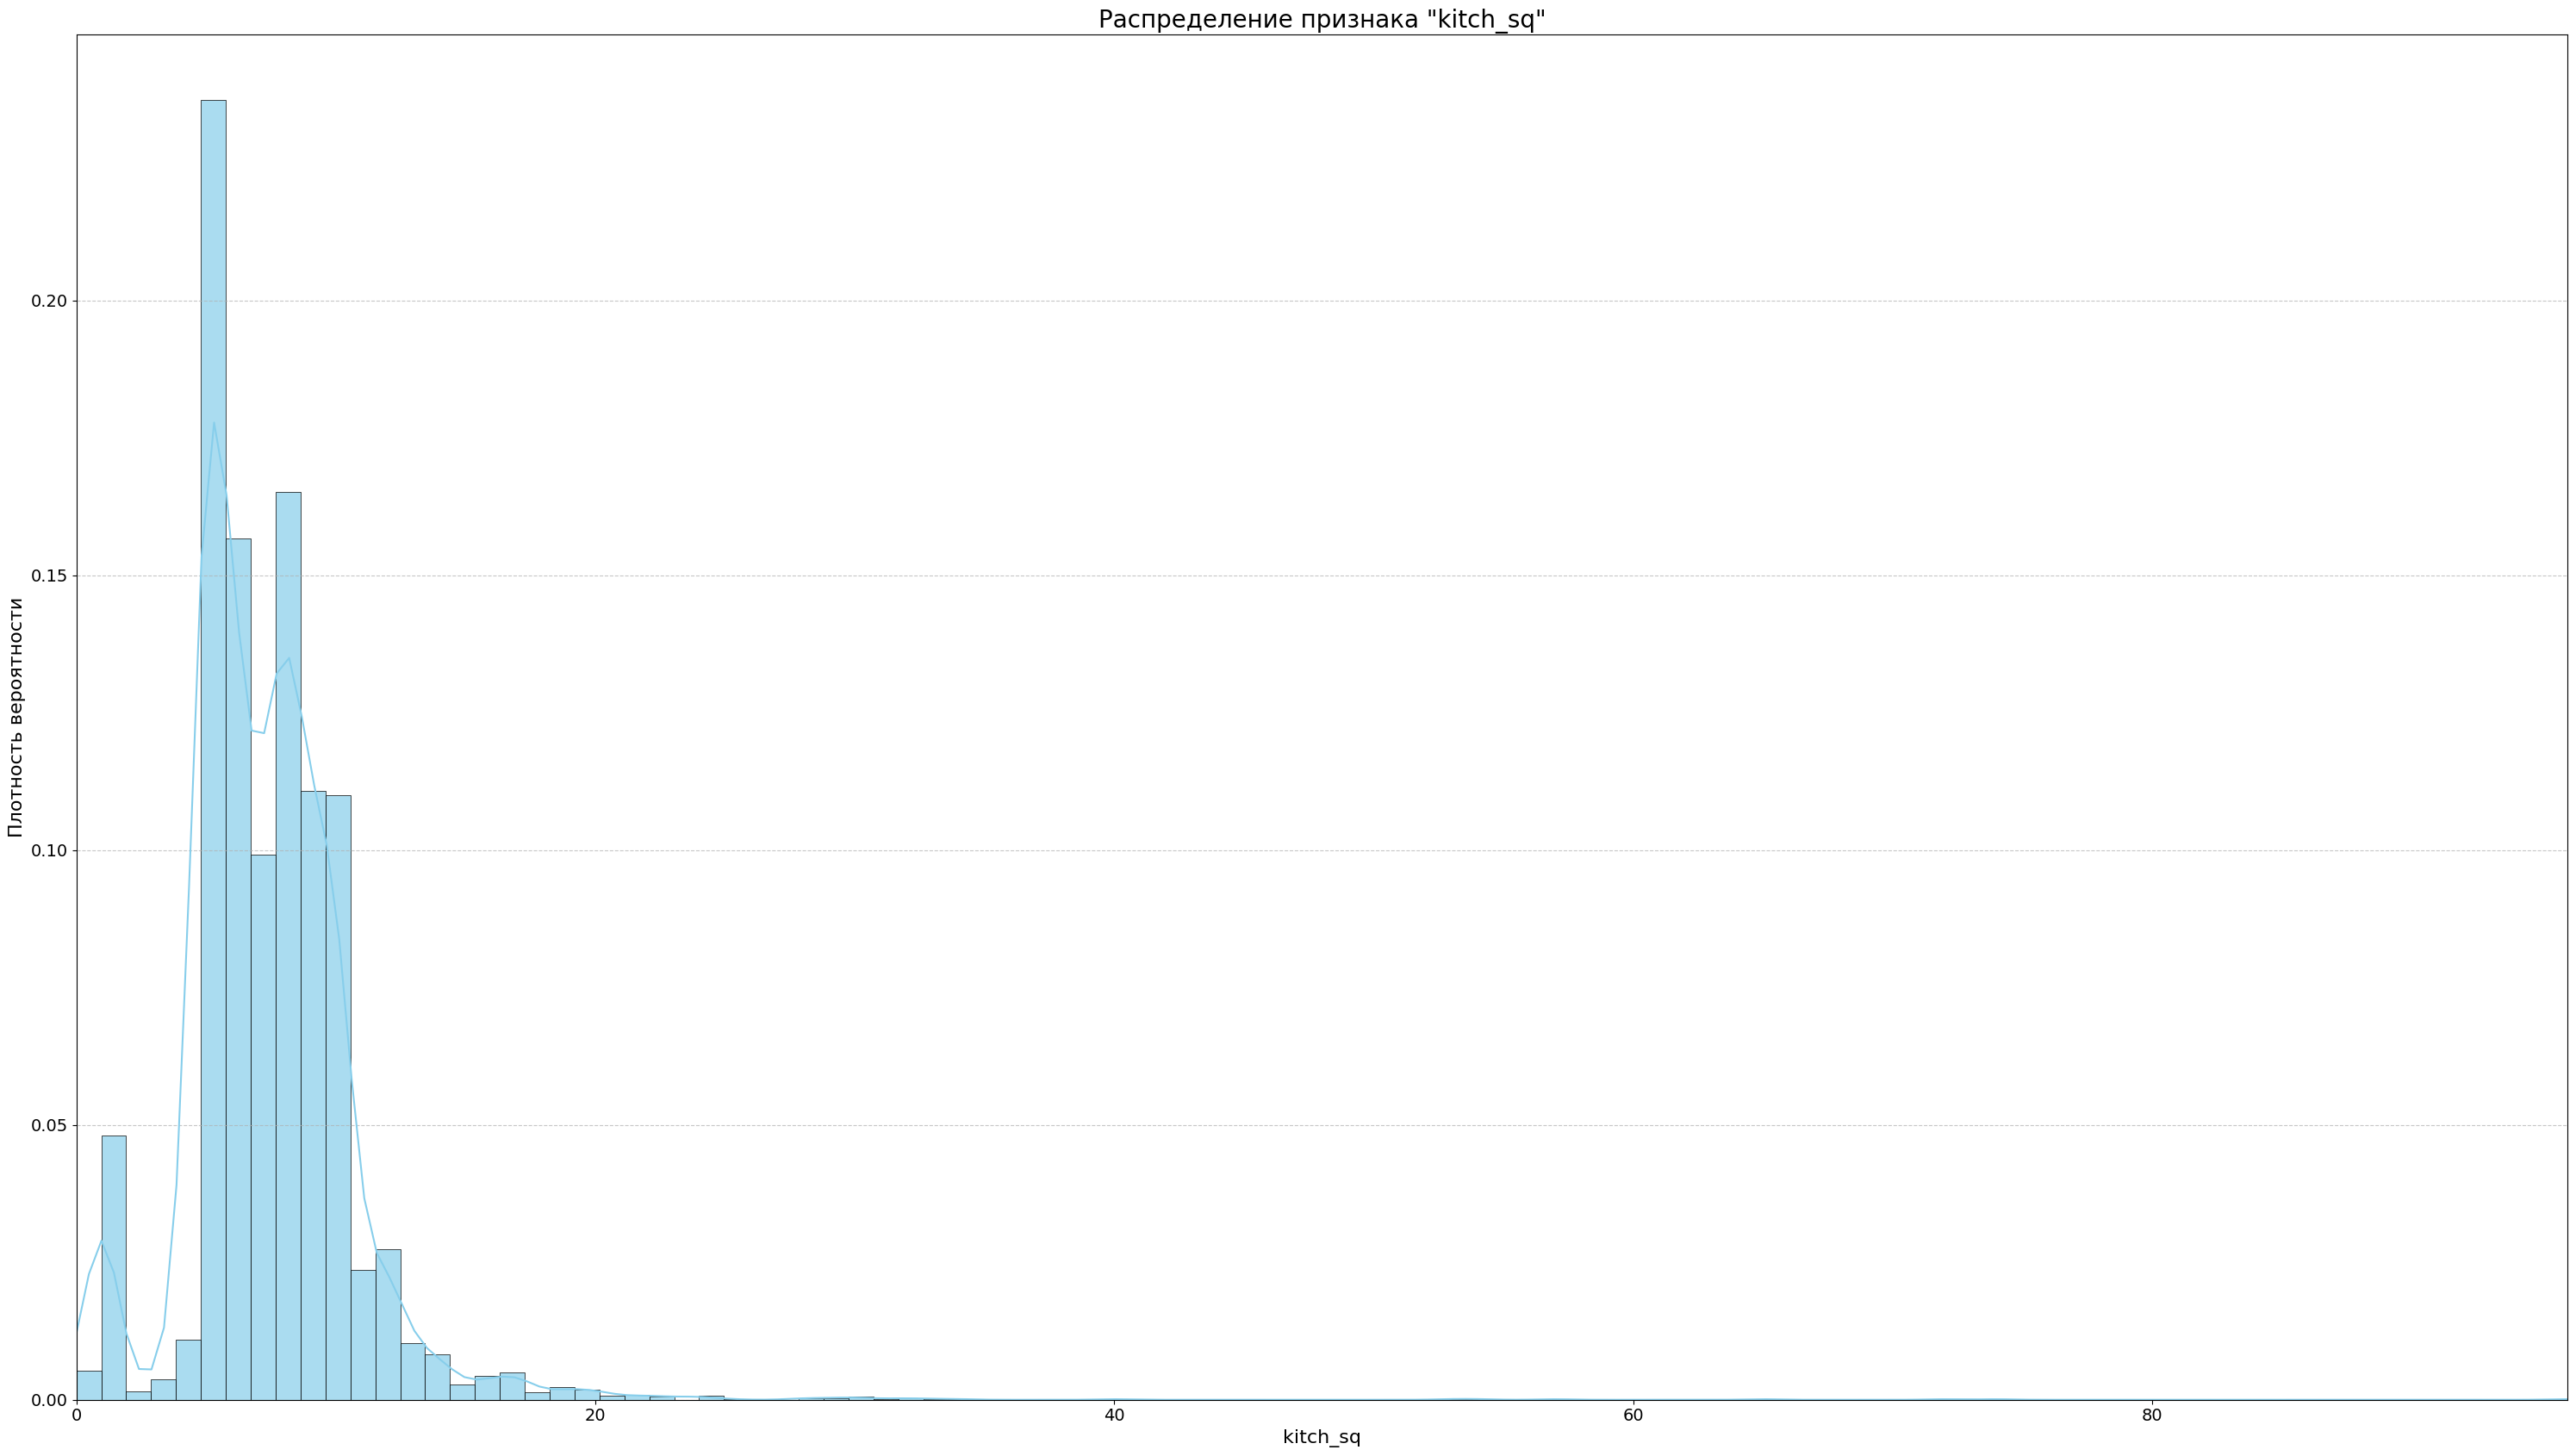

---------------------------------------------------------------------------------------------------------------------------


In [18]:
# Создаём список признаков площадей
squares_list = ['full_sq', 'life_sq', 'kitch_sq']

# Создаём список цветовых гамм
colors_list = ['lightgreen', 'orange', 'skyblue']



# Создаём цикл по признакам площадей
for square, color in zip(squares_list, colors_list):
    
    # Задаём заголовок для графика
    print(f'\n\nГрафик распределения признака "{square}":')
    print('-' * 123)
    
    # Задаём размер полотна
    plt.rcParams['figure.figsize'] = (30, 17)
    
    # Строим график распределения признака
    sns.histplot(
        data = flats_df,
        x = square,
        kde = True,
        bins = 100,
        stat = 'density',
        edgecolor = 'black',
        linewidth = 0.5,
        alpha = 0.7,
        color = color
    )
    
    # Настраиваем параметры
    plt.title(f'Распределение признака "{square}"', fontsize = 20)
    plt.xlabel(square, fontsize = 16)
    plt.ylabel('Плотность вероятности', fontsize = 16)
    plt.xlim(flats_df[square].min(), flats_df[square].max())
    plt.xticks(fontsize = 14)
    plt.yticks(fontsize = 14)
    plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)
    plt.tight_layout()
    
    # Выводим график
    plt.show()
    print('-' * 123)

Теперь посмотрим на распределение признака `num_room`:


График распределения признака "num_room":
---------------------------------------------------------------------------------------------------------------------------


C:\Users\User\AppData\Local\Temp\ipykernel_7680\1591563685.py:11: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




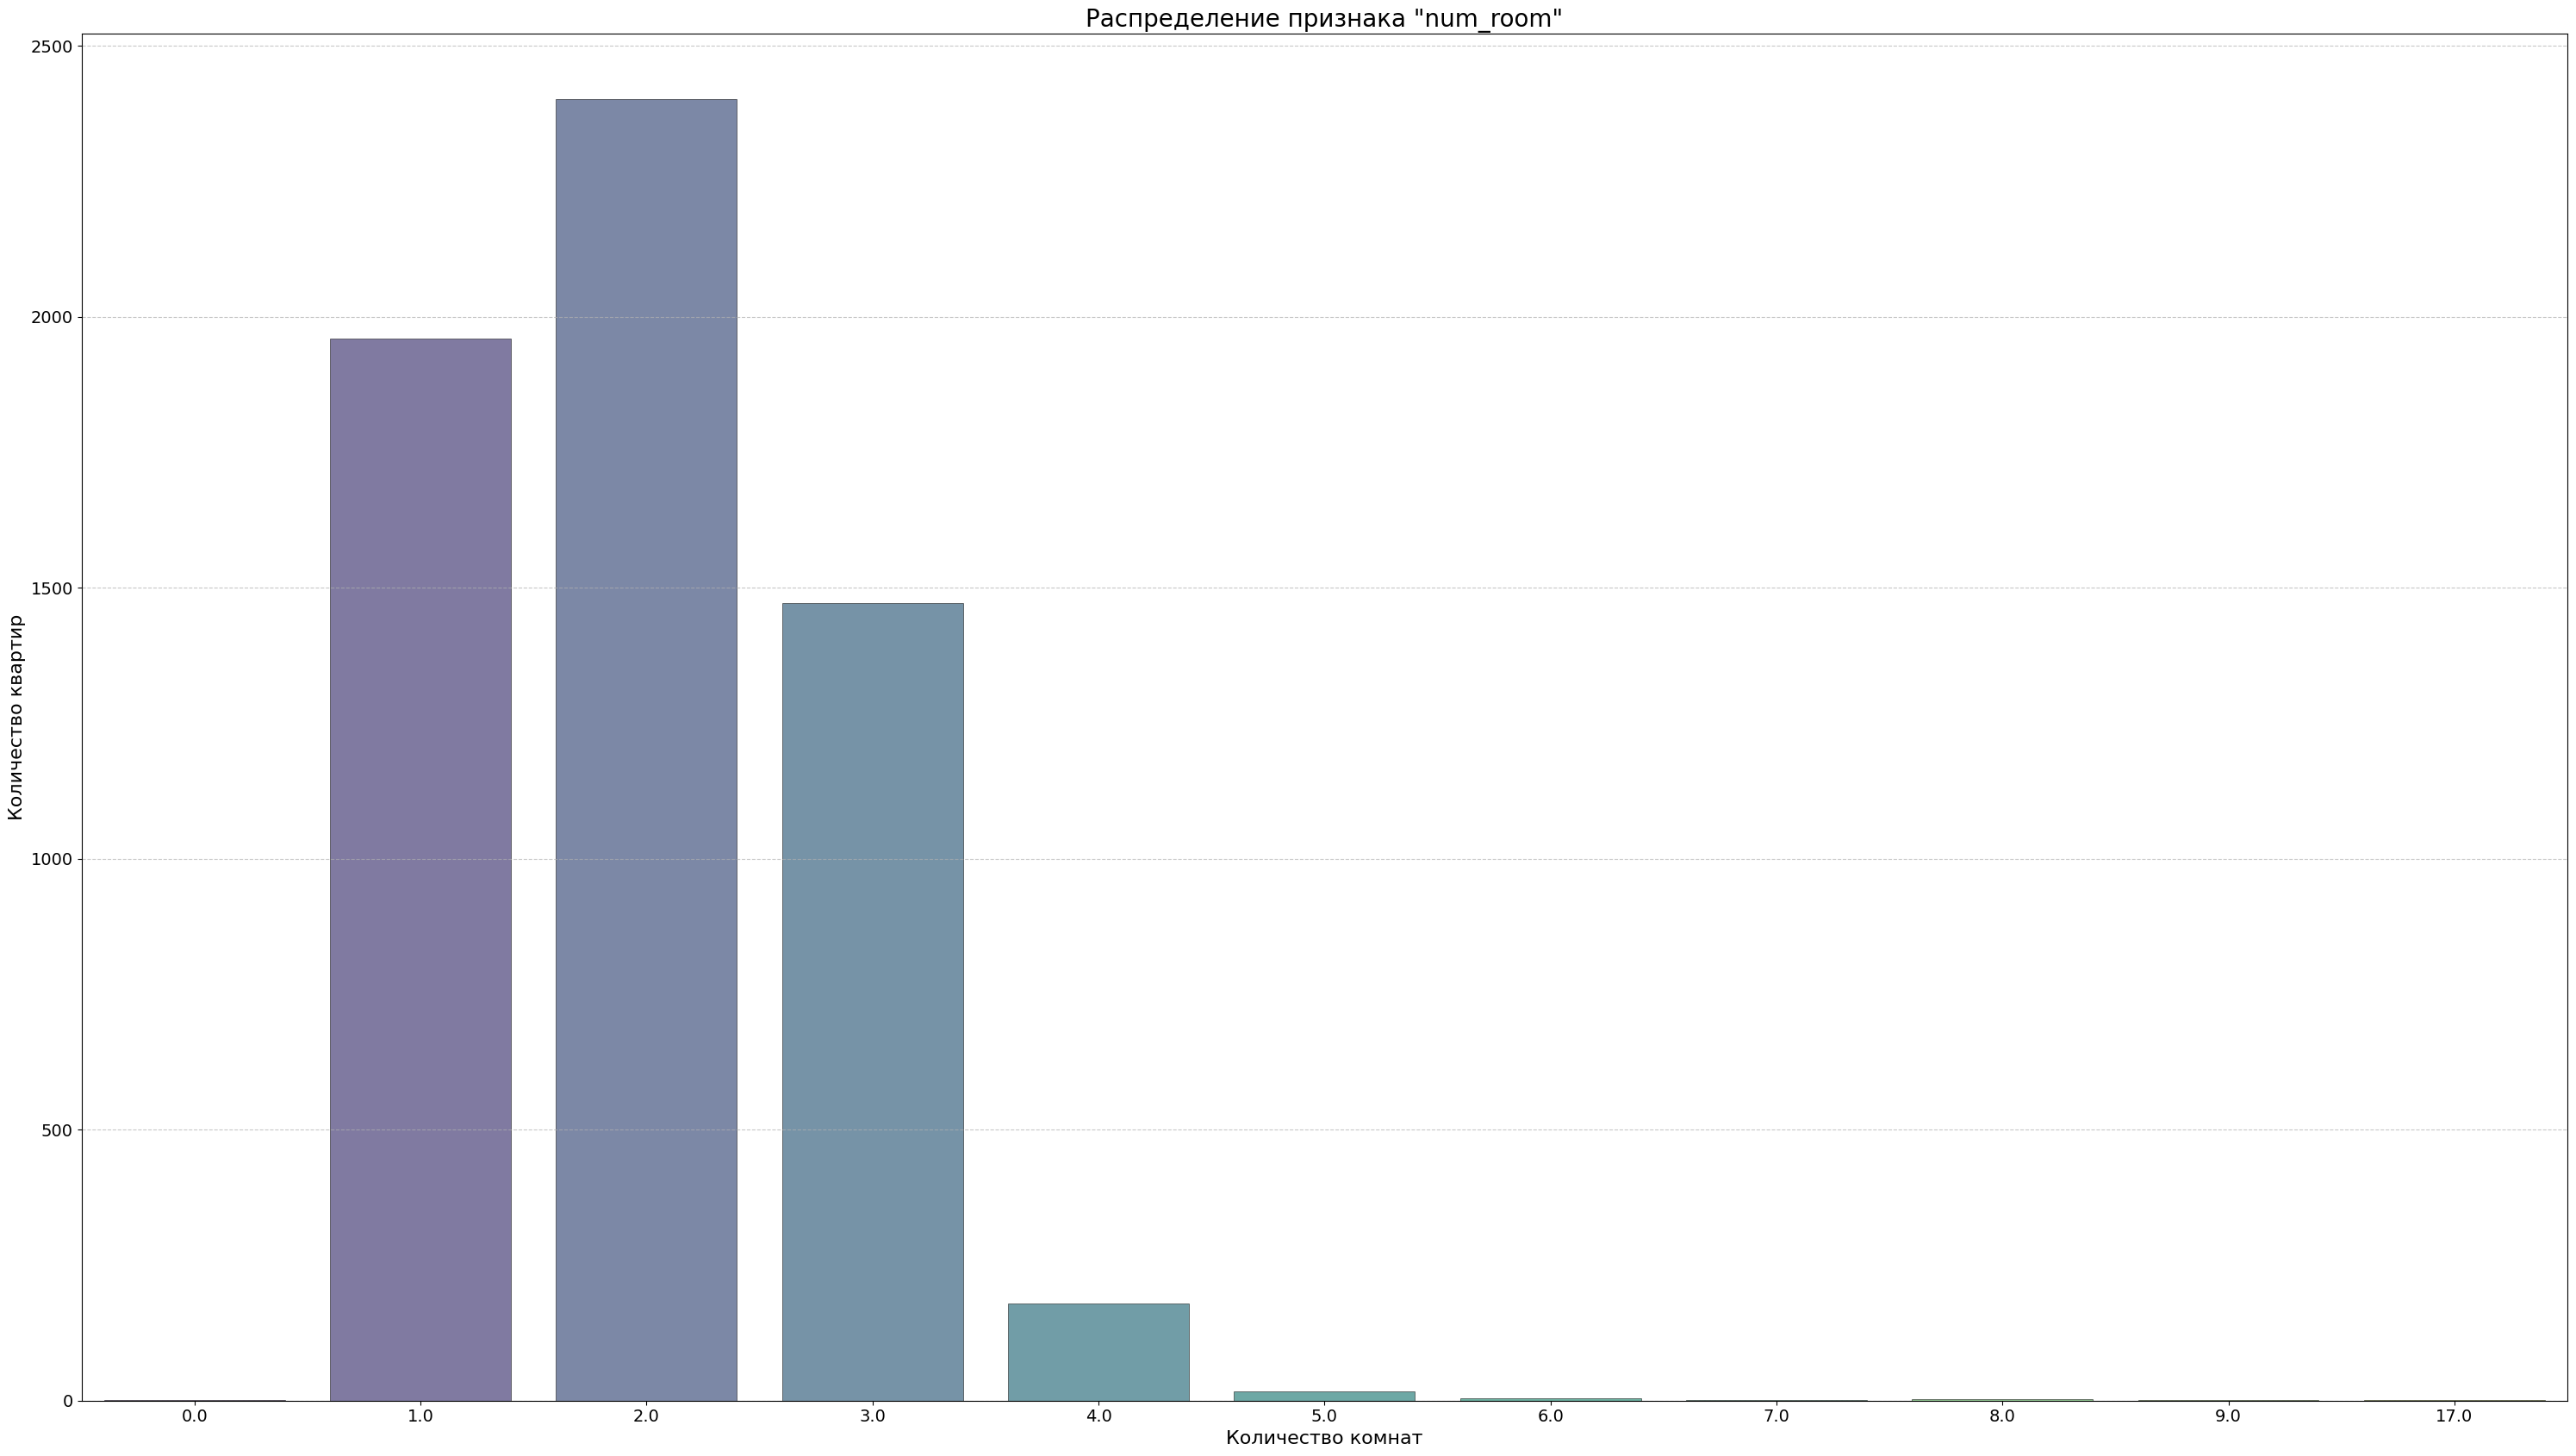

---------------------------------------------------------------------------------------------------------------------------


In [19]:
# Задаём заголовок для графика
print('\nГрафик распределения признака "num_room":')
print('-' * 123)



# Задаём размер полотна
plt.rcParams['figure.figsize'] = (30, 17)

# Строим график распределения признака
sns.countplot(
    data = flats_df,
    x = 'num_room',
    palette = 'viridis',
    edgecolor = 'black',
    linewidth = 0.5,
    alpha = 0.7
)

# Настраиваем параметры
plt.title('Распределение признака "num_room"', fontsize = 20)
plt.xlabel('Количество комнат', fontsize = 16)
plt.ylabel('Количество квартир', fontsize = 16)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)
plt.tight_layout()

# Выводим график
plt.show()
print('-' * 123)

**Вывод:**

По результатам видно, что графики имеют правостороннюю скошенность.

=============================================================================================================================================

## <CENTER> **`4.` Machine Learning**

На данном этапе обучим модели байесовской линейной регрессии и стандартной линейной регрессии, после чего сравним их.

#### $4.1$

##### **Разделение данных.**

Разделим данные на матрицу наблюдений `X` и вектор правильных ответов `y` (для обучения модели были выбраны признаки `full_sq`, `life_sq`, `num_room`, так как данные признаки имеют наибольшую связь с целевой переменной):

In [20]:
# Выделяем матрицу наблюдений и вектор правильных ответов
X = flats_df[['full_sq', 'life_sq', 'num_room']]
y = flats_df['log_price']



# Выводим результаты
check_data_inf(
    data = X,
    data_name = 'X',
    length1 = 40,
    length2 = 65
)

print('\nИнформация по целевой переменной:\n')
display(y.head())
print('-' * 55)


Данные таблицы "X" имеют следующую размерность:

Количество строк: 6042;
Количество признаков (столбцов): 3.
----------------------------------------


,full_sq,life_sq,num_room
0,11,11.0,1.0
1,45,27.0,2.0
2,77,50.0,3.0
3,56,29.0,2.0
4,31,21.0,1.0
...,...,...,...
6037,47,30.0,1.0
6038,56,29.0,2.0
6039,86,59.0,4.0
6040,64,32.0,2.0


-----------------------------------------------------------------

Информация по целевой переменной:



0    14.827111
1    15.775605
2    16.275099
3    16.157316
4    15.640060
Name: log_price, dtype: float64

-------------------------------------------------------


#### $4.2$

#### **Байесовская регрессия.**

Обучаем модель байесовской регрессии:

In [21]:
# Стандартизация внутри модели
with pm.Model() as model:
    
    # Стандартизируем X и y внутри контекста
    X_std = (X - X.mean()) / X.std()
    y_std = (y - y.mean()) / y.std()
    
    # Регистрируем данные как часть модели
    X_data = pm.Data('X', X_std)
    y_data = pm.Data('y', y_std)
    
    # Определяем модель
    betas = pm.Normal(
        'betas', 
        mu = 0, 
        sigma = 10, 
        shape = X.shape[1]
    )
    
    # Определяем стандартное отклонение
    sigma = pm.HalfNormal('sigma', sigma = 1)
    
    # Линейная модель
    mu = pm.math.dot(X_data, betas)
    
    # Ликвидность
    # Используем нормальное распределение для наблюдаемых данных
    likelihood = pm.Normal(
        'likelihood', 
        mu = mu, 
        sigma = sigma, 
        observed = y_data
    )
    
    # MCMC выборка
    trace = pm.sample(
        1000, 
        tune = 500, 
        return_inferencedata = True
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [betas, sigma]


c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\rich\live.py:231: UserWarning:

install "ipywidgets" for Jupyter support

Sampling 4 chains for 500 tune and 1_000 draw iterations (2_000 + 4_000 draws total) took 4027 seconds.


Выводим результат:

In [ ]:
# Выводим результаты выборки
print('\nРезультаты выборки:')
print('-' * 123)
print(f'Количество сэмплов: {len(trace)}')
print(f'Количество параметров: {len(trace.posterior)}')
print('-' * 123)


# Выводим сводную информацию по выборке
print('\nСводная информация по выборке:')
print('-' * 123)
az.summary(trace)


Результаты выборки:
---------------------------------------------------------------------------------------------------------------------------
Количество сэмплов: 4
Количество параметров: 2
---------------------------------------------------------------------------------------------------------------------------

Сводная информация по выборке:
---------------------------------------------------------------------------------------------------------------------------


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
betas[0],0.527,0.024,0.479,0.569,0.001,0.0,2229.0,2204.0,1.0
betas[1],-0.134,0.022,-0.175,-0.095,0.000,0.0,2466.0,2613.0,1.0
betas[2],0.117,0.016,0.086,0.145,0.000,0.0,2690.0,2333.0,1.0
sigma,0.864,0.008,0.850,0.879,0.000,0.0,3345.0,2651.0,1.0


Строим визуализацию:


График с результатами выборки:
---------------------------------------------------------------------------------------------------------------------------


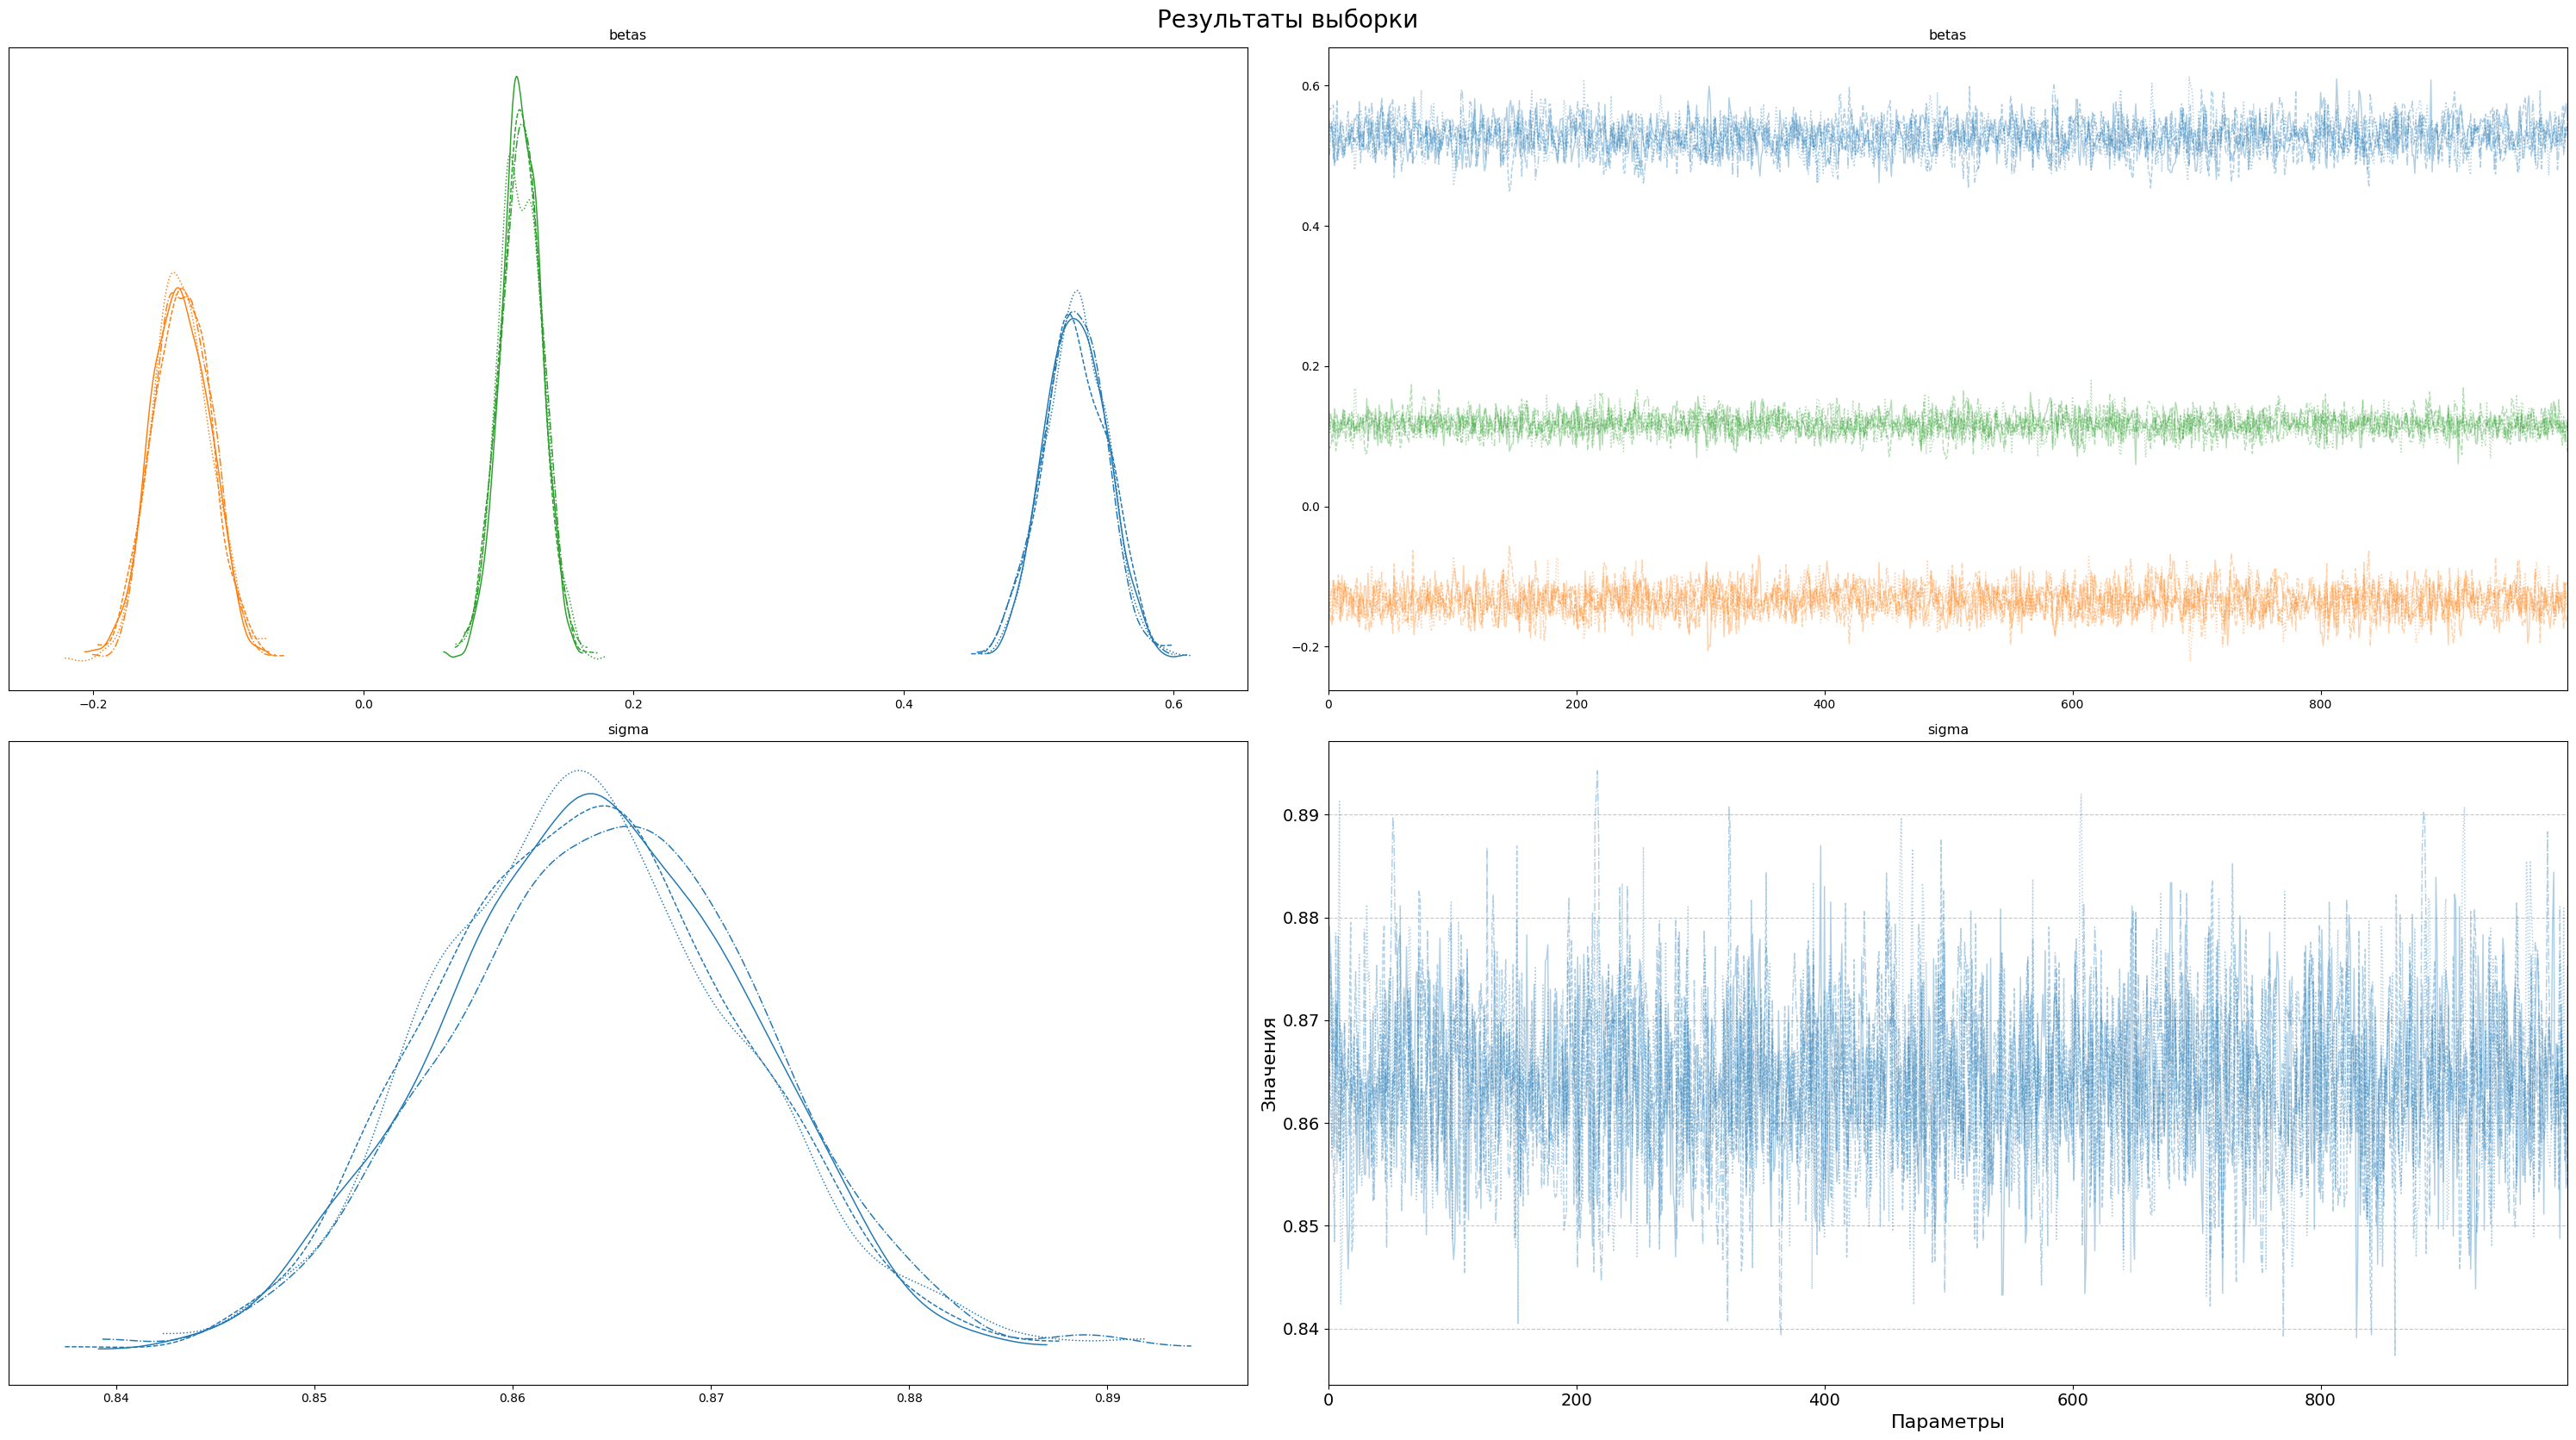

---------------------------------------------------------------------------------------------------------------------------


In [29]:
# Задаём заголовок для графика
print('\nГрафик с результатами выборки:')
print('-' * 123)



# Выводим график с результатами выборки
az.plot_trace(
    trace, 
    figsize = (30, 17),
    var_names = ['betas', 'sigma']
)

# Настраиваем параметры
plt.suptitle('Результаты выборки', fontsize = 20),
plt.xlabel('Параметры', fontsize = 16)
plt.ylabel('Значения', fontsize = 16)
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)
plt.tight_layout(rect = [0, 0.03, 1, 0.95])
plt.tight_layout()

# Выводим график
plt.show()
print('-' * 123)

Строим график распределения коэффициентов:


График распределения коэффициентов:
---------------------------------------------------------------------------------------------------------------------------


<Figure size 2900x2700 with 0 Axes>

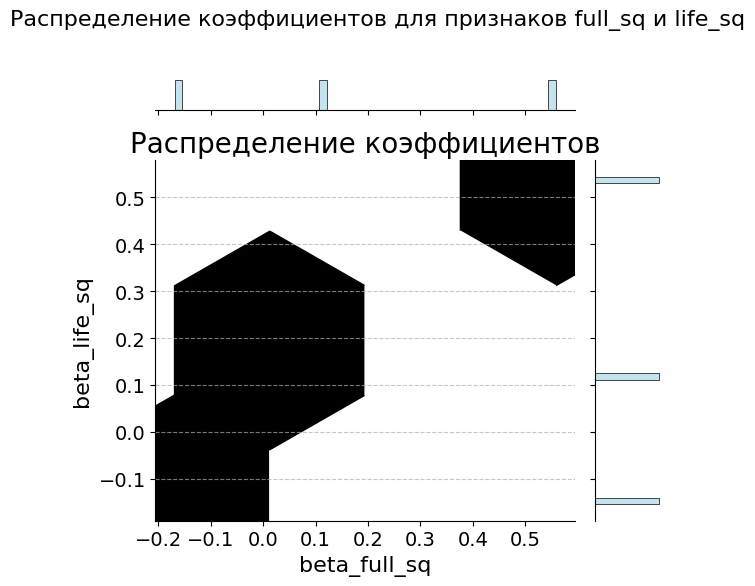

---------------------------------------------------------------------------------------------------------------------------


In [34]:
# Извлекаем коэффициенты 
betas = trace.posterior['betas'].stack(sample = ('chain', 'draw'))



# Задаём заголовок для графика
print('\nГрафик распределения коэффициентов:')
print('-' * 123)

# Выбираем пары для анализа
plt.figure(figsize = (29, 27))

# Строим график распределения коэффициентов
sns.jointplot(
    x = betas[:, 0], 
    y = betas[:, 1], 
    kind = 'hex', 
    color = '#4CB391',
    
    marginal_kws = {
        'bins': 50, 
        'fill': True, 
        'color': 'lightblue', 
        'edgecolor': 'black', 
        'linewidth': 0.5, 
        'alpha': 0.7
    }
    
)

# Настраиваем параметры
plt.title('Распределение коэффициентов', fontsize = 20)
plt.suptitle('Распределение коэффициентов для признаков full_sq и life_sq', fontsize = 16)
plt.tight_layout(rect = [0, 0.03, 1, 0.95])
plt.xticks(fontsize = 14)
plt.yticks(fontsize = 14)
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)
plt.xlabel('beta_full_sq', fontsize = 16)
plt.ylabel('beta_life_sq', fontsize = 16)

# Выводим график
plt.show()
print('-' * 123)

#### $4.3$

#### **Linear Regression.**

Теперь построим модель линейной регрессии из библиотеки `sklearn`.

Для начала стандартизируем выборку `X`:

In [36]:
# Стандартизация признаков
X_std = (X - X.mean()) / X.std()


# Выводим результаты
check_data_inf(
    data = X_std,
    data_name = 'X_std',
    length1 = 40,
    length2 = 40
)


Данные таблицы "X_std" имеют следующую размерность:

Количество строк: 6042;
Количество признаков (столбцов): 3.
----------------------------------------


,full_sq,life_sq,num_room
0,-1.764728,-1.099502,-1.120849
1,-0.348766,-0.307030,0.003349
2,0.983904,0.832147,1.127547
3,0.109340,-0.207971,0.003349
4,-0.931809,-0.604207,-1.120849
...,...,...,...
6037,-0.265474,-0.158442,-1.120849
6038,0.109340,-0.207971,0.003349
6039,1.358718,1.277912,2.251746
6040,0.442507,-0.059383,0.003349


----------------------------------------


Теперь разделим выборку на обучающую и тестовую:

In [39]:
# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X_std,
    y,
    test_size = 0.2,
    random_state = 42,
    shuffle = True
)



# Выводим информацию по обучающей и тестовой выборкам
print('\nИнформация по обучающей выборке X_train:')
check_data_inf(
    data = X_train,
    data_name = 'X_train',
    length1 = 40,
    length2 = 40
)

print('\n\n\nИнформация по тестовой выборке X_test:')
check_data_inf(
    data = X_test,
    data_name = 'X_test',
    length1 = 40,
    length2 = 40
)


Информация по обучающей выборке X_train:

Данные таблицы "X_train" имеют следующую размерность:

Количество строк: 4833;
Количество признаков (столбцов): 3.
----------------------------------------


,full_sq,life_sq,num_room
5966,2.066699,1.228383,1.127547
3939,2.108345,0.980736,0.003349
1094,-0.015598,-0.059383,0.003349
1121,1.941761,1.426501,2.251746
3697,0.817321,0.881677,1.127547
...,...,...,...
3772,-0.598642,-0.604207,-1.120849
5191,-0.640287,-0.653736,-1.120849
5226,0.234277,0.039676,0.003349
5390,1.275426,0.683559,1.127547


----------------------------------------



Информация по тестовой выборке X_test:

Данные таблицы "X_test" имеют следующую размерность:

Количество строк: 1209;
Количество признаков (столбцов): 3.
----------------------------------------


,full_sq,life_sq,num_room
3070,-1.056747,-1.099502,-1.120849
1820,-0.140536,-0.009853,1.127547
4918,-0.265474,-0.604207,-1.120849
3414,-0.556996,-0.406089,0.003349
3950,-0.432058,-0.257501,0.003349
...,...,...,...
2417,-0.931809,-0.158442,-1.120849
3866,0.900613,0.634030,1.127547
2877,-0.348766,-0.207971,0.003349
1219,0.942258,0.138735,0.003349


----------------------------------------


Обучаем модель:

In [41]:
# Создаём объект класса LinearRegression
LR_model = linear_model.LinearRegression()

# Обучаем модель на обучающей выборке
LR_model.fit(X_train, y_train)

# Делаем предсказание на тестовой выборке
y_predictions = LR_model.predict(X_test)

Используем следующие метрики для оценки:

  * **MSE (Mean Squared Error)**: Среднеквадратичная ошибка, основная метрика,

  * **RMSE (Root Mean Squared Error)**: Корень из **MSE**,

  * **R² (коэффициент детерминации)**: Показывает, какую долю дисперсии объясняет модель ($0$–$1$, чем выше, тем лучше).

Создадим функцию для вычисления метрик:

In [43]:
# Создаём функцию 'print_metrics'       
def print_metrics(y_true, y_predict, model_name, decimal_places = 3):
    
    
    """
    Вычисляет и выводит метрики (MSE, RMSE, R², MAE) для оценки модели.
    
    Параметры:
    - y_true: истинные значения (например, y_valid_log)
    - y_pred: предсказанные значения (например, y_lr_predict)
    - model_name: строка с названием модели (например, "LinearRegression")
    - decimal_places: количество знаков после запятой для форматирования (по умолчанию 3)
    
    Возвращает:
    - Словарь с метриками (mse, rmse, r2, mae)
    
    """
    
    
    # Вычисляем метрики
    mse_metric = metrics.mean_squared_error(y_true, y_predict)
    rmse_metric = np.sqrt(mse_metric)
    mae_metric = metrics.mean_absolute_error(y_true, y_predict)
    r2_metric = metrics.r2_score(y_true, y_predict)
    
    
    # Выведем результат
    print(f'\n{model_name} (значения метрик):\n')
    print(f'Mean Squared Error: {mse_metric:.{decimal_places}f}')
    print('-' * 35)
    print(f'Root Mean Squared Error: {rmse_metric:.{decimal_places}f}')
    print('-' * 35)
    print(f'Mean Absolute Error: {mae_metric:.{decimal_places}f}')
    print('-' * 35)
    print(f'R²: {r2_metric:.{decimal_places}f}')
    print('-' * 35)

Считаем метрики:

In [44]:
# Применяем функцию 'print_metrics'  
print_metrics(
    y_true = y_test,
    y_predict = y_predictions,
    model_name = 'LinearRegression',
    decimal_places = 3
)


LinearRegression (значения метрик):

Mean Squared Error: 0.367
-----------------------------------
Root Mean Squared Error: 0.605
-----------------------------------
Mean Absolute Error: 0.387
-----------------------------------
R²: 0.179
-----------------------------------


#### $4.4$

##### **Сравнение результатов моделей.**

Сохраняем коэффициенты классической линейной регрессии:

In [47]:
# Коэффициенты модели
classical_coefs = pd.DataFrame(
    {
        'Feature': X.columns,
        'Coefficients': LR_model.coef_
    }
)



# Выводим коэффициенты модели
print('\nКоэффициенты модели LinearRegression:')
print('-' * 30)
print()

print(classical_coefs)
print('-' * 30)


Коэффициенты модели LinearRegression:
------------------------------

    Feature  Coefficients
0   full_sq      0.379167
1   life_sq     -0.047675
2  num_room      0.043190
------------------------------


Теперь сохраним коэффициенты байесовской линейной регрессии:

In [48]:
# Создаём список признаков для отображения коэффициентов
features = ['full_sq', 'life_sq', 'num_room']

# Извлекаем сводную информацию по выборке
bayes_summary = az.summary(trace, var_names=['betas'])
bayes_coefs = bayes_summary.reset_index()
bayes_coefs = bayes_coefs[bayes_coefs['index'].str.contains('betas')].copy()
bayes_coefs['Feature'] = features  
bayes_coefs = bayes_coefs[['Feature', 'mean', 'hdi_3%', 'hdi_97%']]

Объединим таблицы:

In [51]:
# Объединяем таблицы
comparison = classical_coefs.merge(
    bayes_coefs, 
    on = 'Feature', 
    how = 'left'
)



# Переименовываем столбцы
comparison.columns = ['Feature', 'Classical_Coefficient', 'Bayesian_Mean', 'HDI_3%', 'HDI_97%']

# Выводим таблицу сравнения коэффициентов
print('\nТаблица сравнения коэффициентов:')
print('-' * 35)
print()

print(comparison)
print('-' * 65)


Таблица сравнения коэффициентов:
-----------------------------------

    Feature  Classical_Coefficient  Bayesian_Mean  HDI_3%  HDI_97%
0   full_sq               0.379167          0.527   0.479    0.569
1   life_sq              -0.047675         -0.134  -0.175   -0.095
2  num_room               0.043190          0.117   0.086    0.145
-----------------------------------------------------------------


Построим визуализацию:


График сравнения коэффициентов:
---------------------------------------------------------------------------------------------------------------------------


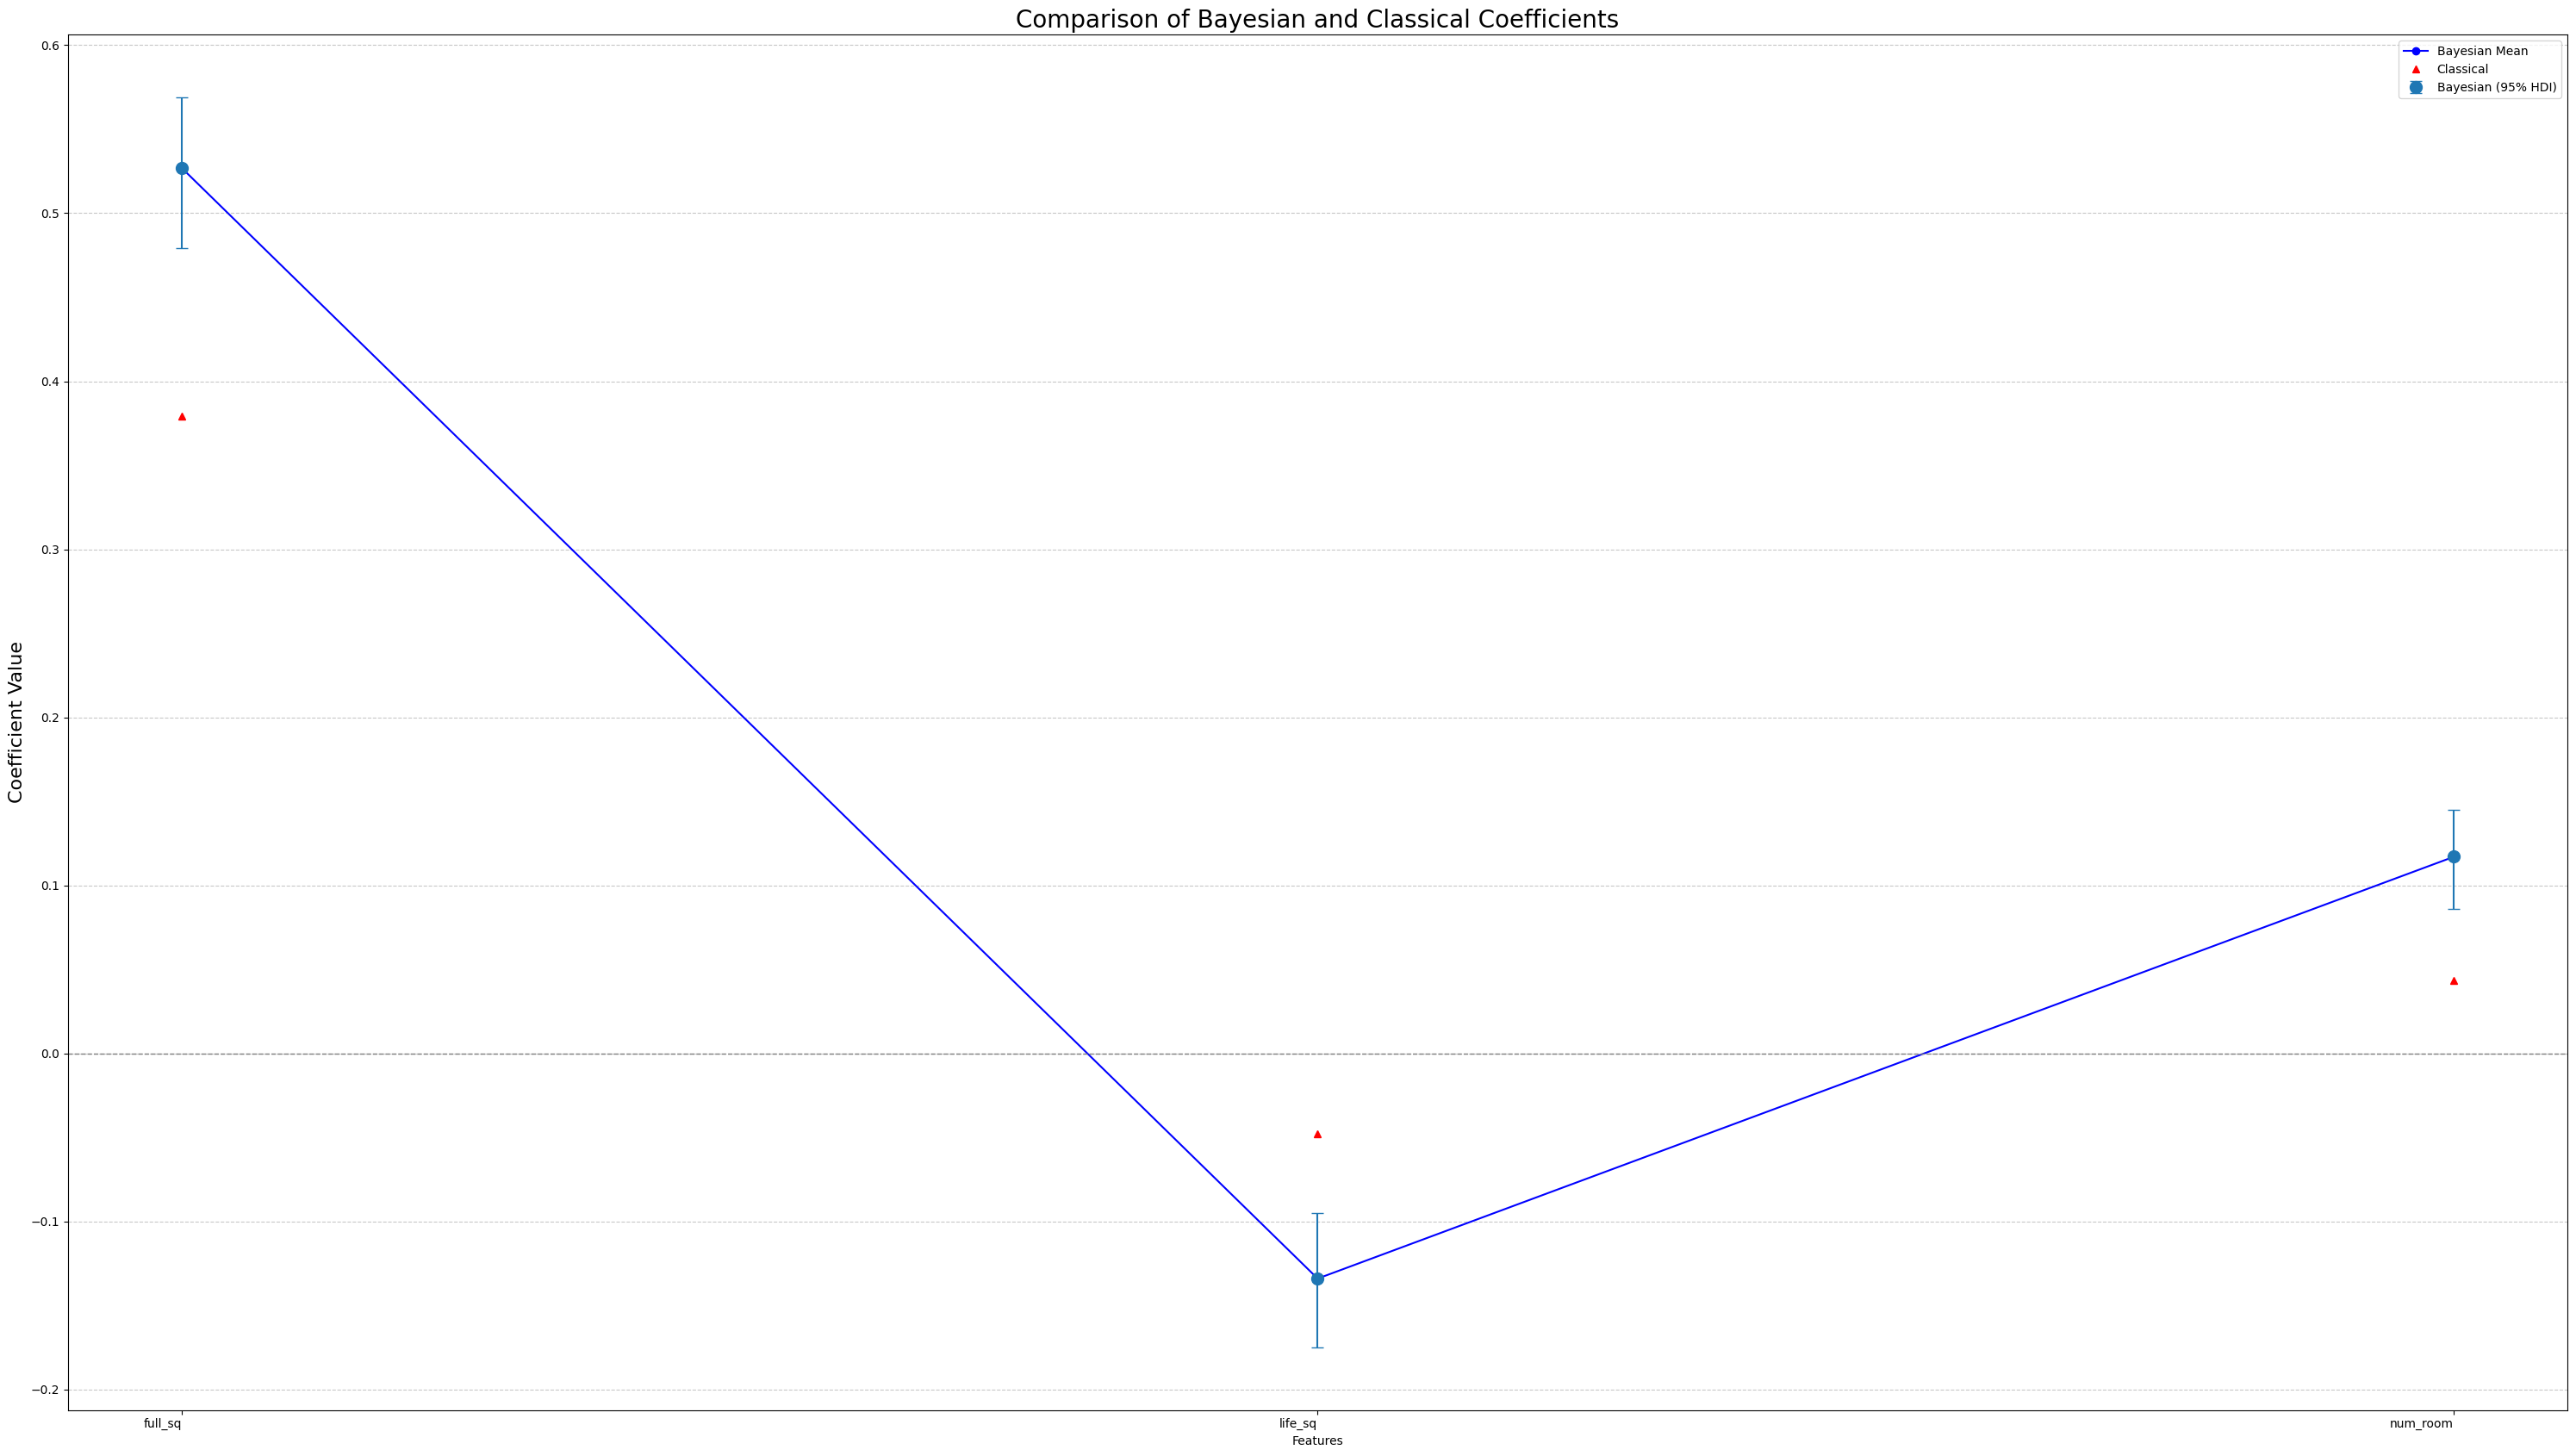

---------------------------------------------------------------------------------------------------------------------------


In [ ]:
# Задаём заголовок для графика
print('\nГрафик сравнения коэффициентов:')
print('-' * 123)



# Настраиваем размер полотна
plt.figure(figsize = (30, 17))

# Строим график сравнения коэффициентов
plt.errorbar(
    comparison['Feature'], comparison['Bayesian_Mean'], 
    yerr = [comparison['Bayesian_Mean'] - comparison['HDI_3%'], comparison['HDI_97%'] - comparison['Bayesian_Mean']],
    fmt = 'o', 
    label = 'Bayesian (95% HDI)',
    #color = 'blue',
    markersize = 10,
    capsize = 5
)

# Настраиваем параметры графика
plt.plot(comparison['Feature'], comparison['Bayesian_Mean'], 'bo-', label = 'Bayesian Mean')
plt.axhline(0, color = 'gray', linestyle = '--', linewidth = 1)
plt.xticks(ha = 'right')
plt.grid(axis = 'y', linestyle = '--', alpha = 0.7)
plt.title('Comparison of Bayesian and Classical Coefficients', fontsize = 20)
plt.ylabel('Coefficient Value', fontsize = 16)
plt.plot(comparison['Feature'], comparison['Classical_Coefficient'], 'r^', label = 'Classical')
plt.xlabel('Features')
plt.legend()
plt.tight_layout()

# Выводим график
plt.show()
print('-' * 123)

**Вывод:**

Общее наблюдение: байесовская модель дает более высокие абсолютные значения коэффициентов с учетом неопределенности (`HDI`), тогда как классическая модель склонна к более консервативным оценкам. Это может быть связано с влиянием приоров в байесовском подходе.

---